<a href="https://colab.research.google.com/github/eduhamuy/eduhamuy-ai/blob/dev/notebooks/02_Search_Exploracion_Entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EduHamuy AI — Construcción, evaluación y selección de la búsqueda

Este Colab construye y compara seis métodos para el buscador académico de EduHamuy: búsqueda literal como línea base, TF-IDF, BM25, embeddings, `hybrid_tfidf_embeddings` y `hybrid_bm25_embeddings`. Todos parten del mismo corpus de PDFs, las mismas consultas y las mismas etiquetas de relevancia.

El flujo completo es:

1. **Cargar documentos** desde Azure Blob Storage.
2. **Extraer y limpiar texto** de los PDFs.
3. **Construir índices** literal, TF-IDF, BM25, embeddings y los dos híbridos.
4. **Recibir y procesar consultas**, transformándolas según cada método.
5. **Calcular relevancia**, ordenar resultados y responder con los documentos mejor posicionados.
6. **Evaluar** con consultas `dev` y `test`, usando Precision@5, Recall@5, MRR y nDCG@5.
6. **Persistir artefactos versionados**, incluyendo configuraciones, metadatos, manifiestos y resultados.
7. **Medir el benchmark operativo**: construcción, latencia, memoria y tamaño.
8. **Seleccionar el método** considerando calidad y compromisos operativos.
9. **Publicar opcionalmente** los artefactos aprobados en Azure.
10. **Preparar el contrato de despliegue** para el backend.
11. **Conservar evidencia reproducible** para la tesis y futuras promociones.
12. **Documentar resultados, limitaciones y siguientes pasos**.

La separación `dev`/`test` es obligatoria para la comparación: `dev` ajusta los pesos `alpha` de los híbridos y `test` permanece aislado para la decisión final. La evaluación actual usa 60 consultas estratificadas en `title`, `content` y `mixed`. El notebook no entrena una red neuronal desde cero: utiliza un modelo multilingüe preentrenado para generar embeddings y compara su señal con los métodos léxicos.

## Tabla de etapas y métodos comparados

Este notebook construye y evalúa seis alternativas para el buscador académico de EduHamuy. Todos los métodos parten del mismo corpus, las mismas consultas y los mismos documentos marcados como relevantes.

| Etapa | Búsqueda literal — línea base | TF-IDF | BM25 | Embeddings | Híbrido TF-IDF + embeddings | Híbrido BM25 + embeddings |
|---|---|---|---|---|---|---|
| 1. Cargar documentos | Leer PDFs desde Azure Blob Storage | Igual | Igual | Igual | Igual | Igual |
| 2. Extraer y limpiar texto | Extraer y limpiar texto | Igual | Igual | Igual | Igual | Igual |
| 3. Construir índices | Texto y términos; no requiere índice complejo | Vectorizador y matriz dispersa | Índice BM25 y frecuencias de términos | Vectores de documentos o fragmentos | Índices TF-IDF y embeddings | Índices BM25 y embeddings |
| 4.1 Recibir consulta | Texto escrito por el usuario | Igual | Igual | Igual | Igual | Igual |
| 4.2 Transformar consulta | Coincidencia de palabras o frases | Aplicar vectorizador | Tokenizar la consulta | Generar embedding | Transformar con TF-IDF y embeddings | Tokenizar con BM25 y generar embedding |
| 4.3 Calcular relevancia | Coincidencias y reglas simples | Similitud coseno | Puntuación BM25 | Similitud entre vectores | Combinar puntuaciones TF-IDF y semántica | Combinar puntuaciones BM25 y semántica |
| 4.4 Ordenar resultados | Ranking por coincidencias | Ranking TF-IDF | Ranking BM25 | Ranking semántico | Ranking combinado | Ranking combinado |
| 4.5 Responder | Documentos coincidentes | Documentos relevantes | Documentos relevantes | Documentos semánticamente relacionados | Ranking combinado | Ranking combinado |
| 5. Evaluar | Línea base | Precision@k, Recall@k, MRR y nDCG | Mismas métricas | Mismas métricas | Mismas métricas | Mismas métricas |
| 6. Guardar artefactos | Texto, títulos y metadatos | Vectorizador, matriz y metadatos | Índice BM25, tokens y metadatos | Embeddings, configuración y metadatos | Configuración y referencias a TF-IDF y embeddings | Configuración y referencias a BM25 y embeddings |
| 7. Benchmark operativo | Tiempo y recursos de referencia | Igual | Igual | Igual | Igual | Igual |
| 8. Decisión experimental | Comparación de calidad y operación | Igual | Igual | Igual | Igual | Igual |
| 9. Publicar artefactos | Publicación versionada | Igual | Igual | Igual | Igual | Igual |
| 10. Contrato y despliegue | Backend con texto | Backend con artefactos TF-IDF | Backend con índice BM25 | Backend con índice vectorial | Backend con índices TF-IDF y embeddings | Backend con índices BM25 y embeddings |

La tabla resume el flujo conceptual. La persistencia física se ejecuta después del ajuste y la evaluación para guardar los `alpha` finales, los resultados y el contrato reproducible. Los dos híbridos se mantienen durante la evaluación para comparar qué representación léxica combina mejor con embeddings. El backend y el frontend seguirán utilizando el método seleccionado después de comparar resultados.


## Preparación técnica — Instalación de dependencias

rank_bm25 se utiliza para BM25 y sentence-transformers para embeddings multilingües. El modelo de embeddings puede tardar en descargarse y consumir más memoria que TF-IDF.


In [1]:
!pip install -q azure-storage-blob joblib scipy pandas numpy scikit-learn nltk matplotlib seaborn rank-bm25 sentence-transformers pypdf psutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.7/455.7 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 32.8 MB/s eta 0:00:00


## Preparación técnica — Importaciones y configuración

In [2]:
import io
import json
import math
import os
import re
import warnings
import unicodedata
from pathlib import Path
from datetime import datetime, timezone
import hashlib

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import scipy.sparse
import seaborn as sns
from azure.storage.blob import BlobServiceClient
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from rank_bm25 import BM25Okapi
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")

for resource_path, resource_name in [
    ("tokenizers/punkt", "punkt"),
    ("tokenizers/punkt_tab", "punkt_tab"),
    ("corpora/stopwords", "stopwords"),
]:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(resource_name)

# Este notebook trabaja exclusivamente con el ambiente DEV.
TARGET_ENV = "dev"
CORPUS_VERSION = "2026-10-07-v1"
SUITE_VERSION = "2026-10-07-v1"
SOURCE_CONTAINER = "ai-source-dev"
EVALUATION_CONTAINER = "ai-evaluation-dev"
ARTIFACT_CONTAINER = "ai-artifacts-dev"
CORPUS_PREFIX = f"corpora/{CORPUS_VERSION}/pdfs/"
EVALUATION_BLOB = f"suites/{SUITE_VERSION}/evaluation_queries.csv"
PUBLISH_ARTIFACTS = True




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 1. Cargar documentos

En Colab User Secrets deben existir AZURE_STORAGE_ACCOUNT y AZURE_STORAGE_SAS. Nunca se deben escribir credenciales en una celda.


In [3]:
try:
    from google.colab import userdata

    def get_secret(name):
        return (userdata.get(name) or "").strip()
except ImportError:
    def get_secret(name):
        return os.getenv(name, "").strip()

account = get_secret("AZURE_STORAGE_ACCOUNT")
sas = get_secret("AZURE_STORAGE_SAS").lstrip("?")

if not account or not sas:
    raise ValueError("Configura AZURE_STORAGE_ACCOUNT y AZURE_STORAGE_SAS.")

service = BlobServiceClient(
    account_url=f"https://{account}.blob.core.windows.net",
    credential=sas,
)
source_container = service.get_container_client(SOURCE_CONTAINER)
evaluation_container = service.get_container_client(EVALUATION_CONTAINER)
artifact_container = service.get_container_client(ARTIFACT_CONTAINER)

print(f"Cuenta configurada: {account}")
print(f"Ambiente: {TARGET_ENV}")
print(f"Corpus: {SOURCE_CONTAINER}/{CORPUS_PREFIX}")
print(f"Suite: {EVALUATION_CONTAINER}/{EVALUATION_BLOB}")
print(f"Contenedor de artefactos: {ARTIFACT_CONTAINER}")


Cuenta configurada: steduhamuyshared
Ambiente: dev
Corpus: ai-source-dev/corpora/2026-10-07-v1/pdfs/
Suite: ai-evaluation-dev/suites/2026-10-07-v1/evaluation_queries.csv
Contenedor de artefactos: ai-artifacts-dev


## 1.1 Leer PDFs desde Azure Blob Storage

Este notebook reconstruye el corpus DEV desde `ai-source-dev` y el prefijo versionado configurado. La primera ejecución deja `REBUILD_FROM_PDFS=True` para asegurar que los índices y la auditoría parten de los PDFs fuente, no de artefactos anteriores.


In [4]:
# La primera ejecución contra un corpus DEV siempre parte de sus PDFs.
REBUILD_FROM_PDFS = True
LOCAL_ROOT = Path("/content/eduhamuy-search-artifacts") / CORPUS_VERSION
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
skipped_no_text = []
skipped_errors = []

def download_blob_bytes(container, name):
    return container.get_blob_client(name).download_blob().readall()

def normalize_document_reference(value):
    return unicodedata.normalize("NFC", str(value)).strip()

def title_from_path(path):
    return normalize_document_reference(path).replace(".pdf", "").replace("+", " ").strip()

def extract_documents_from_pdfs():
    extracted = []
    skipped_no_text = []
    skipped_errors = []

    for blob in source_container.list_blobs(name_starts_with=CORPUS_PREFIX):
        if not blob.name.lower().endswith(".pdf"):
            continue

        try:
            pdf_bytes = source_container.download_blob(blob.name).readall()
            reader = PdfReader(io.BytesIO(pdf_bytes))
            text_parts = []

            for page in reader.pages:
                page_text = page.extract_text() or ""
                if page_text.strip():
                    text_parts.append(page_text)

            text = "\n".join(text_parts).strip()
            if not text:
                skipped_no_text.append(blob.name)
                continue

            document_path = normalize_document_reference(blob.name[len(CORPUS_PREFIX):])
            extracted.append({
                "document_path": document_path,
                "source_blob_path": blob.name,
                "text_content": text,
                "document_title": title_from_path(document_path),
                "document_words": len(text.split()),
            })
        except Exception as exc:
            skipped_errors.append({
                "document_path": blob.name,
                "error": type(exc).__name__,
            })

    if not extracted:
        raise ValueError("No se pudo extraer texto de ningún PDF.")

    return pd.DataFrame(extracted), skipped_no_text, skipped_errors

if REBUILD_FROM_PDFS:
    documents, skipped_no_text, skipped_errors = extract_documents_from_pdfs()
    tfidf_vectorizer = None
    X_tfidf = None
    print(f"PDF procesados: {len(documents)}")
    print(f"PDF sin texto: {len(skipped_no_text)}")
    print(f"PDF con error: {len(skipped_errors)}")
else:
    documents = pd.read_csv(
        io.BytesIO(download_blob_bytes(artifact_container, "processed_documents.csv"))
    )
    tfidf_vectorizer = joblib.load(
        io.BytesIO(download_blob_bytes(artifact_container, "tfidf_vectorizer.joblib"))
    )
    X_tfidf = scipy.sparse.load_npz(
        io.BytesIO(download_blob_bytes(artifact_container, "X_tfidf.npz"))
    )
    print("Se reutilizaron los artefactos TF-IDF actuales.")

required_columns = {"document_path", "document_title", "text_content"}
missing = required_columns - set(documents.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing)}")

print(f"Documentos cargados: {len(documents)}")
display(documents[["document_title", "document_path", "document_words"]].head())


PDF procesados: 216
PDF sin texto: 0
PDF con error: 0
Documentos cargados: 216


,document_title,document_path,document_words
0,"1 El que tiene que pensar soy yo, no la comput...","1+El+que+tiene+que+pensar+soy+yo,+no+la+comput...",6260
1,1 Galindo,1+Galindo.pdf,8473
2,1 La Carrera de Trabajo Social UMSS. Esbozo hi...,1+La+Carrera+de+Trabajo+Social+UMSS.+Esbozo+hi...,9314
3,1 Raciolingüismo en adultos mayores,1+Raciolingüismo+en+adultos+mayores.pdf,6686
4,1. B581,1.+B581.pdf,6891


# 2. Extraer y limpiar texto

In [5]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    normalized = text.lower()
    normalized = re.sub(r"\d+", "", normalized)
    normalized = re.sub(r"[^a-záéíóúüñ\s]", "", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()

    try:
        tokens = word_tokenize(normalized, language="spanish")
    except LookupError:
        tokens = normalized.split()

    stop_words = set(stopwords.words("spanish"))
    return " ".join(token for token in tokens if token not in stop_words)

documents["cleaned_text"] = documents["text_content"].fillna("").map(preprocess_text)
documents["tokens"] = documents["cleaned_text"].str.split()
print("Preprocesamiento terminado.")

if tfidf_vectorizer is None:
    tfidf_vectorizer = TfidfVectorizer()
    X_tfidf = tfidf_vectorizer.fit_transform(documents["cleaned_text"])
    print("Se construyó un nuevo índice TF-IDF desde el corpus.")
else:
    if X_tfidf.shape[0] != len(documents):
        raise ValueError("Las filas de X_tfidf no coinciden con los documentos.")
    if X_tfidf.shape[1] != len(tfidf_vectorizer.vocabulary_):
        raise ValueError("Las columnas de X_tfidf no coinciden con el vocabulario.")

print(f"Matriz TF-IDF: {X_tfidf.shape}")


Preprocesamiento terminado.
Se construyó un nuevo índice TF-IDF desde el corpus.
Matriz TF-IDF: (216, 64186)


## Preparación para la etapa 5 — Consultas y relevancia humana

La evaluación necesita un archivo `evaluation_queries.csv` con estas columnas mínimas:

- `query_id`
- `query`
- `split`: `dev` o `test`
- `relevant_documents`: rutas documentales separadas por `|`
- `query_type`: `title`, `content` o `mixed`

El archivo actual contiene 60 consultas estratificadas: 20 basadas principalmente en títulos, 20 cuya relevancia depende del contenido y 20 mixtas. Cada grupo contiene 10 consultas `dev` y 10 `test`. La columna `query_type` permite comprobar posteriormente que ningún método se beneficia solo de un tipo de consulta.

Las etiquetas de relevancia siguen siendo una anotación humana inicial y deben revisarse leyendo el título, resumen o contenido del PDF. Las consultas `dev` sirven para ajustar por separado el peso `alpha` de cada variante híbrida; las consultas `test` se reservan para la comparación final.

In [6]:
try:
    evaluation_bytes = evaluation_container.download_blob(EVALUATION_BLOB).readall()
except Exception as exc:
    raise FileNotFoundError(
        f"No se encontró la suite DEV en {EVALUATION_CONTAINER}/{EVALUATION_BLOB}."
    ) from exc

evaluation_queries = pd.read_csv(io.BytesIO(evaluation_bytes)).fillna("")
evaluation_queries["relevant_documents"] = evaluation_queries["relevant_documents"].map(
    lambda value: "|".join(
        normalize_document_reference(item)
        for item in str(value).split("|")
        if item
    )
)
required_evaluation_columns = {
    "query_id", "query", "split", "relevant_documents", "query_type"
}
missing_evaluation_columns = required_evaluation_columns - set(evaluation_queries.columns)
if missing_evaluation_columns:
    raise ValueError(
        "evaluation_queries.csv no tiene las columnas requeridas: "
        f"{sorted(missing_evaluation_columns)}"
    )

if evaluation_queries["query_id"].duplicated().any():
    raise ValueError("La suite contiene query_id duplicados.")

def sha256_bytes(value):
    return hashlib.sha256(value).hexdigest()

def audit_dev_corpus_and_suite():
    documents_by_reference = {}
    corpus_documents = []

    for blob in source_container.list_blobs(name_starts_with=CORPUS_PREFIX):
        if not blob.name.lower().endswith(".pdf"):
            continue
        raw_pdf = source_container.download_blob(blob.name).readall()
        reference_name = normalize_document_reference(blob.name[len(CORPUS_PREFIX):])
        record = {
            "document_id": f"doc-{sha256_bytes(raw_pdf)[:16]}",
            "blob_path": blob.name,
            "sha256": sha256_bytes(raw_pdf),
            "bytes": len(raw_pdf),
        }
        corpus_documents.append(record)
        documents_by_reference.setdefault(reference_name, []).append(record)

    if not corpus_documents:
        raise ValueError(f"No se encontraron PDFs en {SOURCE_CONTAINER}/{CORPUS_PREFIX}.")

    query_ids_by_reference = {}
    for row in evaluation_queries.itertuples(index=False):
        for reference_name in filter(None, str(row.relevant_documents).split("|")):
            query_ids_by_reference.setdefault(reference_name, []).append(row.query_id)

    missing = sorted(
        reference_name
        for reference_name in query_ids_by_reference
        if reference_name not in documents_by_reference
    )
    ambiguous = sorted(
        reference_name
        for reference_name, matches in documents_by_reference.items()
        if reference_name in query_ids_by_reference and len(matches) != 1
    )
    if missing or ambiguous:
        details = {"missing": missing, "ambiguous": ambiguous}
        raise ValueError(
            "La suite no corresponde al corpus DEV: "
            + json.dumps(details, ensure_ascii=False)
        )

    corpus_manifest = {
        "environment": TARGET_ENV,
        "corpus_version": CORPUS_VERSION,
        "source_container": SOURCE_CONTAINER,
        "source_prefix": CORPUS_PREFIX,
        "document_count": len(corpus_documents),
        "documents": sorted(corpus_documents, key=lambda item: item["blob_path"]),
    }
    suite_manifest = {
        "environment": TARGET_ENV,
        "suite_version": SUITE_VERSION,
        "corpus_version": CORPUS_VERSION,
        "evaluation_blob": EVALUATION_BLOB,
        "evaluation_file_sha256": sha256_bytes(evaluation_bytes),
        "query_count": int(len(evaluation_queries)),
        "required_documents": [
            {
                **documents_by_reference[reference_name][0],
                "query_ids": sorted(query_ids),
            }
            for reference_name, query_ids in sorted(query_ids_by_reference.items())
        ],
    }
    return corpus_manifest, suite_manifest

corpus_manifest, suite_manifest = audit_dev_corpus_and_suite()
with open(LOCAL_ROOT / "corpus_manifest.json", "w", encoding="utf-8") as file:
    json.dump(corpus_manifest, file, ensure_ascii=False, indent=2)
with open(LOCAL_ROOT / "suite_manifest.json", "w", encoding="utf-8") as file:
    json.dump(suite_manifest, file, ensure_ascii=False, indent=2)

print(f"PDFs auditados en DEV: {corpus_manifest['document_count']}")
print(f"PDFs protegidos por la suite: {len(suite_manifest['required_documents'])}")
display(evaluation_queries)


PDFs auditados en DEV: 216
PDFs protegidos por la suite: 61


,query_id,query,split,relevant_documents,query_type
0,q001,trabajo social y transformación curricular,dev,1+La+Carrera+de+Trabajo+Social+UMSS.+Esbozo+hi...,title
1,q002,crisis y reforma de la universidad pública,dev,Pensar+para+actuar+Un+diálogo+académico+sobre+...,title
2,q003,"raciolingüismo, castellano andino y quechua",dev,1+Raciolingüismo+en+adultos+mayores.pdf|5+ANAL...,title
3,q004,descolonización e interculturalidad,dev,2.+Descolonización+e+interculturalidad_Finzi_V...,title
4,q005,formación universitaria y valores estudiantiles,dev,2+LA+INFLUENCIA+DE+LA+UNIVERSIDAD+Y+L+AGLOBALI...,title
5,q006,motivación académica en la educación superior ...,dev,1+Galindo.pdf,title
6,q007,tecnología digital en los procesos de aprendiz...,dev,4+La+Tecnología+Digital+en+los+procesos+de+Apr...,title
7,q008,percepciones de investigadores sobre la invest...,dev,percepciones.pdf,title
8,q009,gestión del conocimiento y comunidades de apre...,dev,6+IDENTIDADES+5+Juan+Lara.pdf,title
9,q010,conflictividad universitaria como objeto de es...,dev,Aproximación+a+la+conflictividad+universitaria...,title


# 3. Construir índices
## 3.1 Índice literal — línea base

La línea base cuenta los términos de la consulta que aparecen en cada documento y añade una pequeña bonificación si aparece la frase completa. No es un modelo de IA.


In [7]:
def rank_scores(scores, method, query, top_n=5):
    scores = np.asarray(scores, dtype=float)
    indices = np.argsort(scores)[::-1][:top_n]
    rows = []
    for index in indices:
        score = float(scores[index])
        if score <= 0:
            continue
        row = documents.iloc[int(index)]
        rows.append({
            "method": method,
            "query": query,
            "document_title": str(row["document_title"]),
            "document_path": str(row["document_path"]),
            "score": round(score, 6),
        })
    return pd.DataFrame(rows)

def literal_scores(query):
    cleaned_query = preprocess_text(query)
    query_tokens = cleaned_query.split()
    if not query_tokens:
        return np.zeros(len(documents))

    query_set = set(query_tokens)
    values = []
    for text in documents["cleaned_text"]:
        document_set = set(text.split())
        overlap = len(query_set & document_set) / len(query_set)
        phrase_bonus = 0.25 if cleaned_query in text else 0.0
        values.append(overlap + phrase_bonus)
    return np.asarray(values)

def literal_search(query, top_n=5):
    return rank_scores(literal_scores(query), "literal", query, top_n)


## 3.2 Índice TF-IDF

In [8]:
def tfidf_scores(query):
    cleaned_query = preprocess_text(query)
    if not cleaned_query:
        return np.zeros(len(documents))
    query_vector = tfidf_vectorizer.transform([cleaned_query])
    return cosine_similarity(query_vector, X_tfidf).ravel()

def tfidf_search(query, top_n=5):
    return rank_scores(tfidf_scores(query), "tfidf", query, top_n)


## 3.3 Índice BM25

In [9]:
bm25 = BM25Okapi(documents["tokens"].tolist())

def bm25_scores(query):
    tokens = preprocess_text(query).split()
    if not tokens:
        return np.zeros(len(documents))
    return np.asarray(bm25.get_scores(tokens))

def bm25_search(query, top_n=5):
    return rank_scores(bm25_scores(query), "bm25", query, top_n)


## 3.4 Índice de embeddings

Se utiliza un modelo multilingüe previamente entrenado. No se entrena una red neuronal desde cero. Esta primera versión genera un vector por documento; dividir documentos extensos en fragmentos queda como mejora futura.


In [10]:
RUN_EMBEDDINGS = True
EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

if RUN_EMBEDDINGS:
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    semantic_text = (
        documents["document_title"].fillna("")
        + ". "
        + documents["text_content"].fillna("")
    ).tolist()
    document_embeddings = embedding_model.encode(
        semantic_text,
        batch_size=16,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    document_embeddings = np.asarray(document_embeddings)
    print(f"Embeddings generados: {document_embeddings.shape}")
else:
    embedding_model = None
    document_embeddings = None
    print("Embeddings desactivados.")


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Embeddings generados: (216, 384)


In [11]:
def embedding_scores(query):
    if embedding_model is None:
        raise RuntimeError("RUN_EMBEDDINGS está desactivado.")
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True,
    )[0]
    return document_embeddings @ query_embedding

def embedding_search(query, top_n=5):
    return rank_scores(embedding_scores(query), "embeddings", query, top_n)


## 3.5 Índices híbridos

Se comparan dos variantes híbridas, cada una con su propio peso `alpha` ajustado en consultas `dev`:

- `hybrid_tfidf_embeddings`: combina la señal léxica de TF-IDF con la señal semántica de embeddings.
- `hybrid_bm25_embeddings`: combina la señal léxica de BM25 con la señal semántica de embeddings.

Para ambas variantes:

```text
score_final = alpha × score_lexical_normalizado
              + (1 - alpha) × score_embeddings_normalizado
```

El valor de `alpha` se ajusta por separado usando consultas `dev` y se mantiene fijo durante `test`. BM25 y embeddings también se evalúan de forma independiente, para comprobar si la combinación aporta una mejora real.


In [12]:
def minmax_normalize(scores):
    scores = np.asarray(scores, dtype=float)
    minimum = scores.min()
    maximum = scores.max()
    if maximum == minimum:
        return np.zeros_like(scores)
    return (scores - minimum) / (maximum - minimum)


def hybrid_tfidf_embeddings_scores(query, alpha=0.5):
    if embedding_model is None:
        raise RuntimeError("Los embeddings son necesarios.")
    lexical = minmax_normalize(tfidf_scores(query))
    semantic = minmax_normalize(embedding_scores(query))
    return alpha * lexical + (1 - alpha) * semantic


def hybrid_tfidf_embeddings_search(query, top_n=5, alpha=0.5):
    return rank_scores(
        hybrid_tfidf_embeddings_scores(query, alpha),
        "hybrid_tfidf_embeddings",
        query,
        top_n,
    )


def hybrid_bm25_embeddings_scores(query, alpha=0.5):
    if embedding_model is None:
        raise RuntimeError("Los embeddings son necesarios.")
    lexical = minmax_normalize(bm25_scores(query))
    semantic = minmax_normalize(embedding_scores(query))
    return alpha * lexical + (1 - alpha) * semantic


def hybrid_bm25_embeddings_search(query, top_n=5, alpha=0.5):
    return rank_scores(
        hybrid_bm25_embeddings_scores(query, alpha),
        "hybrid_bm25_embeddings",
        query,
        top_n,
    )


def make_hybrid_searcher(method_name, score_function, alpha):
    return lambda query, k: rank_scores(
        score_function(query, alpha),
        method_name,
        query,
        k,
    )


# 4. Recibir, transformar, ordenar y responder consultas

## 4.1 Recibir la consulta

El usuario proporciona una consulta textual, que puede ser una palabra, una frase o un párrafo.

## 4.2 Transformar la consulta

Cada método transforma la consulta de forma diferente: coincidencia literal, vector TF-IDF, tokens BM25, embedding semántico o una combinación de señales.

## 4.3 Calcular relevancia

Se calcula una puntuación mediante coincidencias, similitud coseno, BM25, similitud vectorial o una combinación normalizada.

## 4.4 Ordenar resultados

Los documentos se ordenan por su puntuación para construir el ranking de resultados.

## 4.5 Responder

El buscador devuelve la ruta, el título y la puntuación de los documentos mejor posicionados.

In [13]:
def run_all_methods(query, top_n=5, alpha_tfidf=0.5, alpha_bm25=0.5):
    outputs = [
        literal_search(query, top_n),
        tfidf_search(query, top_n),
        bm25_search(query, top_n),
    ]
    if embedding_model is not None:
        outputs.extend([
            embedding_search(query, top_n),
            hybrid_tfidf_embeddings_search(query, top_n, alpha_tfidf),
            hybrid_bm25_embeddings_search(query, top_n, alpha_bm25),
        ])
    return pd.concat(outputs, ignore_index=True)

for query in [
    "educación superior",
    "desigualdad educativa y universidad pública",
    "salud mental en estudiantes",
]:
    print(f"Resultados para: {query}")
    display(run_all_methods(query, top_n=5, alpha_tfidf=0.5, alpha_bm25=0.5))


Resultados para: educación superior


,method,query,document_title,document_path,score
0,literal,educación superior,percepciones,percepciones.pdf,1.250000
1,literal,educación superior,art6_5,art6_5.pdf,1.250000
2,literal,educación superior,dyliancastellon_01,dyliancastellon_01.pdf,1.250000
3,literal,educación superior,Reflexiones sobre la problemática del poder y...,Reflexiones+sobre+la+problemática+del+poder++y...,1.250000
4,literal,educación superior,Reseña del libro Resistencias ecolingüísticas,Reseña+del+libro+Resistencias+ecolingüísticas.pdf,1.250000
5,tfidf,educación superior,9 IDENTIDADES 5 Proyecto-Guido Machaca,9+IDENTIDADES+5+Proyecto-Guido+Machaca.pdf,0.249703
6,tfidf,educación superior,3 De la Educación virtual a la Educación Prese...,3+De+la+Educación+virtual+a+la+Educación+Prese...,0.246079
7,tfidf,educación superior,2. Descolonización e interculturalidad_Finzi_V...,2.+Descolonización+e+interculturalidad_Finzi_V...,0.197637
8,tfidf,educación superior,Presentacion Quinto Número,Presentacion+Quinto+Número.pdf,0.172835
9,tfidf,educación superior,1 Galindo,1+Galindo.pdf,0.167303


Resultados para: desigualdad educativa y universidad pública


,method,query,document_title,document_path,score
0,literal,desigualdad educativa y universidad pública,TRASPATIOS 5_3,TRASPATIOS+5_3.pdf,1.000000
1,literal,desigualdad educativa y universidad pública,5. B585,5.+B585.pdf,1.000000
2,literal,desigualdad educativa y universidad pública,Reseña 1 Emma Lazcano.,Reseña+1+Emma+Lazcano..pdf,0.750000
3,literal,desigualdad educativa y universidad pública,percepciones,percepciones.pdf,0.750000
4,literal,desigualdad educativa y universidad pública,Una mirada a la economía social y solidaria e...,Una+mirada+a+la+economía+social+y++solidaria+e...,0.750000
5,tfidf,desigualdad educativa y universidad pública,9 IDENTIDADES 5 Proyecto-Guido Machaca,9+IDENTIDADES+5+Proyecto-Guido+Machaca.pdf,0.111473
6,tfidf,desigualdad educativa y universidad pública,rasgos distintivos,rasgos+distintivos.pdf,0.107818
7,tfidf,desigualdad educativa y universidad pública,Pensar para actuar Un diálogo académico sobre ...,Pensar+para+actuar+Un+diálogo+académico+sobre+...,0.101949
8,tfidf,desigualdad educativa y universidad pública,¿Y ahora que hacemos_,¿Y+ahora+que+hacemos_.pdf,0.095275
9,tfidf,desigualdad educativa y universidad pública,La crisis del Modelo Educativo en la Universi...,La+crisis+del+Modelo+Educativo++en+la+Universi...,0.095257


Resultados para: salud mental en estudiantes


,method,query,document_title,document_path,score
0,literal,salud mental en estudiantes,5,5.pdf,1.250000
1,literal,salud mental en estudiantes,6 Posibles efectos consecuentes de las Intelig...,6+Posibles+efectos+consecuentes+de+las+Intelig...,1.250000
2,literal,salud mental en estudiantes,TRASPATIOS 7,TRASPATIOS+7.pdf,1.000000
3,literal,salud mental en estudiantes,America Latina,America+Latina.pdf,1.000000
4,literal,salud mental en estudiantes,Enfermedd de Chagas,Enfermedd+de+Chagas.pdf,1.000000
5,tfidf,salud mental en estudiantes,6 Posibles efectos consecuentes de las Intelig...,6+Posibles+efectos+consecuentes+de+las+Intelig...,0.469337
6,tfidf,salud mental en estudiantes,5,5.pdf,0.362089
7,tfidf,salud mental en estudiantes,De la teoria a la practica,De+la+teoria+a+la+practica.pdf,0.210834
8,tfidf,salud mental en estudiantes,1 Galindo,1+Galindo.pdf,0.202435
9,tfidf,salud mental en estudiantes,64ac2eae8a445,64ac2eae8a445.pdf,0.201503


# 5. Evaluar métodos de búsqueda

Las métricas utilizan los documentos marcados como relevantes:

- Precision@5.
- Recall@5.
- MRR.
- nDCG@5.

Si relevant_documents está vacío, se pueden revisar resultados, pero no calcular una evaluación académica válida.


In [14]:
def parse_relevant_documents(value):
    if not isinstance(value, str) or not value.strip():
        return set()
    return {item.strip() for item in value.split("|") if item.strip()}

def precision_at_k(retrieved, relevant, k=5):
    return len(set(retrieved[:k]) & relevant) / k

def recall_at_k(retrieved, relevant, k=5):
    return len(set(retrieved[:k]) & relevant) / len(relevant) if relevant else 0.0

def reciprocal_rank(retrieved, relevant):
    for position, path in enumerate(retrieved, start=1):
        if path in relevant:
            return 1.0 / position
    return 0.0

def ndcg_at_k(retrieved, relevant, k=5):
    gains = [1 if path in relevant else 0 for path in retrieved[:k]]
    dcg = sum(gain / math.log2(pos + 2) for pos, gain in enumerate(gains))
    ideal = sorted(gains, reverse=True)
    ideal_dcg = sum(gain / math.log2(pos + 2) for pos, gain in enumerate(ideal))
    return dcg / ideal_dcg if ideal_dcg else 0.0


In [15]:
SEARCHERS = {
    "literal": lambda query, k: literal_search(query, k),
    "tfidf": lambda query, k: tfidf_search(query, k),
    "bm25": lambda query, k: bm25_search(query, k),
}
if embedding_model is not None:
    SEARCHERS["embeddings"] = lambda query, k: embedding_search(query, k)
    SEARCHERS["hybrid_tfidf_embeddings"] = make_hybrid_searcher(
        "hybrid_tfidf_embeddings",
        hybrid_tfidf_embeddings_scores,
        0.5,
    )
    SEARCHERS["hybrid_bm25_embeddings"] = make_hybrid_searcher(
        "hybrid_bm25_embeddings",
        hybrid_bm25_embeddings_scores,
        0.5,
    )

def evaluate_method(method_name, rows, k=5):
    detail = []
    for _, row in rows.iterrows():
        relevant = parse_relevant_documents(row["relevant_documents"])
        if not relevant:
            continue
        result = SEARCHERS[method_name](row["query"], k)
        retrieved = result["document_path"].tolist()
        detail.append({
            "method": method_name,
            "query_id": row["query_id"],
            "split": row["split"],
            "precision_at_5": precision_at_k(retrieved, relevant, k),
            "recall_at_5": recall_at_k(retrieved, relevant, k),
            "mrr": reciprocal_rank(retrieved, relevant),
            "ndcg_at_5": ndcg_at_k(retrieved, relevant, k),
        })
    return pd.DataFrame(detail)

annotated = evaluation_queries[
    evaluation_queries["relevant_documents"].astype(str).str.strip() != ""
]
if annotated.empty:
    print("Completa evaluation_queries.csv para calcular las métricas.")
else:
    detail_tables = [
        evaluate_method(method, annotated)
        for method in SEARCHERS
    ]
    evaluation_detail = pd.concat(detail_tables, ignore_index=True)
    evaluation_summary = evaluation_detail.groupby("method")[
        ["precision_at_5", "recall_at_5", "mrr", "ndcg_at_5"]
    ].mean().sort_values("ndcg_at_5", ascending=False)
    display(evaluation_summary)


,precision_at_5,recall_at_5,mrr,ndcg_at_5
method,,,,
hybrid_bm25_embeddings,0.223333,0.880556,0.841389,0.854773
bm25,0.210000,0.838889,0.799722,0.821245
hybrid_tfidf_embeddings,0.226667,0.894444,0.795000,0.819875
embeddings,0.210000,0.826389,0.776389,0.792306
tfidf,0.203333,0.815278,0.728056,0.755777
literal,0.156667,0.694444,0.563333,0.617595


## 5.1 Ajustar `alpha` con consultas `dev`

El peso de la búsqueda léxica y semántica debe ajustarse solo con consultas dev. El conjunto test se reserva para la evaluación final.


In [16]:
def tune_hybrid_alpha(rows, score_function, method_name, candidates=None, k=5):
    if embedding_model is None:
        raise RuntimeError("Los embeddings son necesarios.")
    if candidates is None:
        candidates = np.arange(0.0, 1.01, 0.1)
    dev = rows[
        (rows["split"] == "dev")
        & (rows["relevant_documents"].astype(str).str.strip() != "")
    ]
    if dev.empty:
        print(f"No hay consultas dev anotadas para {method_name}.")
        return None

    records = []
    for alpha in candidates:
        scores = []
        for _, row in dev.iterrows():
            relevant = parse_relevant_documents(row["relevant_documents"])
            result = rank_scores(
                score_function(row["query"], alpha),
                method_name,
                row["query"],
                k,
            )
            scores.append(
                ndcg_at_k(result["document_path"].tolist(), relevant, k)
            )
        records.append({"alpha": float(alpha), "mean_ndcg_at_5": np.mean(scores)})

    tuning = pd.DataFrame(records)
    best_alpha = float(
        tuning.sort_values("mean_ndcg_at_5", ascending=False).iloc[0]["alpha"]
    )
    display(tuning)
    print(f"Mejor alpha en dev para {method_name}: {best_alpha:.2f}")
    return best_alpha


## 5.2 Evaluación final separada: `dev` y `test`

El conjunto `dev` se usa únicamente para ajustar por separado el peso `alpha` de `hybrid_tfidf_embeddings` y `hybrid_bm25_embeddings`. El conjunto `test` queda reservado para comparar todos los métodos con los ajustes ya fijados. La tabla `evaluation_summary_test` y su gráfico son la evidencia principal para elegir el método.

El conjunto está estratificado por `query_type` (`title`, `content` y `mixed`). Las celdas siguientes generan también tablas y gráficos por categoría para confirmar que el ganador no depende de un solo tipo de consulta.

In [17]:
METHOD_ORDER = [
    "literal",
    "tfidf",
    "bm25",
    "embeddings",
    "hybrid_tfidf_embeddings",
    "hybrid_bm25_embeddings",
]
METRIC_COLUMNS = ["precision_at_5", "recall_at_5", "mrr", "ndcg_at_5"]
HYBRID_SCORE_FUNCTIONS = {
    "hybrid_tfidf_embeddings": hybrid_tfidf_embeddings_scores,
    "hybrid_bm25_embeddings": hybrid_bm25_embeddings_scores,
}
HYBRID_ALPHA_USED = {
    method: 0.5
    for method in HYBRID_SCORE_FUNCTIONS
}

if "annotated" not in globals() or annotated.empty:
    print("Completa evaluation_queries.csv antes de evaluar.")
else:
    if embedding_model is not None:
        for method, score_function in HYBRID_SCORE_FUNCTIONS.items():
            tuned_alpha = tune_hybrid_alpha(
                annotated,
                score_function,
                method,
                k=5,
            )
            if tuned_alpha is not None:
                HYBRID_ALPHA_USED[method] = tuned_alpha
                SEARCHERS[method] = make_hybrid_searcher(
                    method,
                    score_function,
                    tuned_alpha,
                )

    # Recalcular todos los métodos después de fijar ambos alpha con dev.
    detail_tables = [
        evaluate_method(method, annotated)
        for method in SEARCHERS
    ]
    evaluation_detail = pd.concat(detail_tables, ignore_index=True)

    dev_detail = evaluation_detail[
        evaluation_detail["split"] == "dev"
    ]
    test_detail = evaluation_detail[
        evaluation_detail["split"] == "test"
    ]

    evaluation_summary_dev = (
        dev_detail.groupby("method", sort=False)[METRIC_COLUMNS]
        .mean()
        .reindex([m for m in METHOD_ORDER if m in dev_detail["method"].unique()])
    )
    evaluation_summary_test = (
        test_detail.groupby("method", sort=False)[METRIC_COLUMNS]
        .mean()
        .reindex([m for m in METHOD_ORDER if m in test_detail["method"].unique()])
        .sort_values("ndcg_at_5", ascending=False)
    )
    evaluation_summary = evaluation_summary_test

    print("alpha utilizados en los híbridos:", HYBRID_ALPHA_USED)
    print("Resultados de desarrollo (solo para ajuste):")
    display(evaluation_summary_dev)
    print("Resultados finales de prueba (test):")
    display(evaluation_summary_test)

    winner = evaluation_summary_test.index[0]
    print(f"Mejor método por nDCG@5 en test: {winner}")


,alpha,mean_ndcg_at_5
0,0.0,0.697065
1,0.1,0.716283
2,0.2,0.745241
3,0.3,0.763818
4,0.4,0.742608
5,0.5,0.753482
6,0.6,0.729700
7,0.7,0.726426
8,0.8,0.706245
9,0.9,0.707139


Mejor alpha en dev para hybrid_tfidf_embeddings: 0.30


,alpha,mean_ndcg_at_5
0,0.0,0.697065
1,0.1,0.705065
2,0.2,0.742565
3,0.3,0.754153
4,0.4,0.761504
5,0.5,0.779907
6,0.6,0.786885
7,0.7,0.786885
8,0.8,0.788562
9,0.9,0.760856


Mejor alpha en dev para hybrid_bm25_embeddings: 0.80
alpha utilizados en los híbridos: {'hybrid_tfidf_embeddings': 0.30000000000000004, 'hybrid_bm25_embeddings': 0.8}
Resultados de desarrollo (solo para ajuste):


,precision_at_5,recall_at_5,mrr,ndcg_at_5
method,,,,
literal,0.153333,0.661111,0.536667,0.592792
tfidf,0.213333,0.808333,0.671667,0.709502
bm25,0.206667,0.788889,0.710556,0.737292
embeddings,0.193333,0.730556,0.677778,0.697065
hybrid_tfidf_embeddings,0.213333,0.805556,0.747222,0.763818
hybrid_bm25_embeddings,0.206667,0.813889,0.767778,0.788562


Resultados finales de prueba (test):


,precision_at_5,recall_at_5,mrr,ndcg_at_5
method,,,,
hybrid_tfidf_embeddings,0.226667,0.938889,0.916667,0.927357
hybrid_bm25_embeddings,0.226667,0.922222,0.916667,0.915326
bm25,0.213333,0.888889,0.888889,0.905199
embeddings,0.226667,0.922222,0.875000,0.887547
tfidf,0.193333,0.822222,0.784444,0.802052
literal,0.160000,0.727778,0.590000,0.642397


Mejor método por nDCG@5 en test: hybrid_tfidf_embeddings


## 5.3 Tablas y gráficos de calidad

El gráfico usa exclusivamente `evaluation_summary_test`, después de ajustar por separado ambos híbridos con consultas `dev`. El orden visual se fija como: literal, TF-IDF, BM25, embeddings, `hybrid_tfidf_embeddings` y `hybrid_bm25_embeddings`.


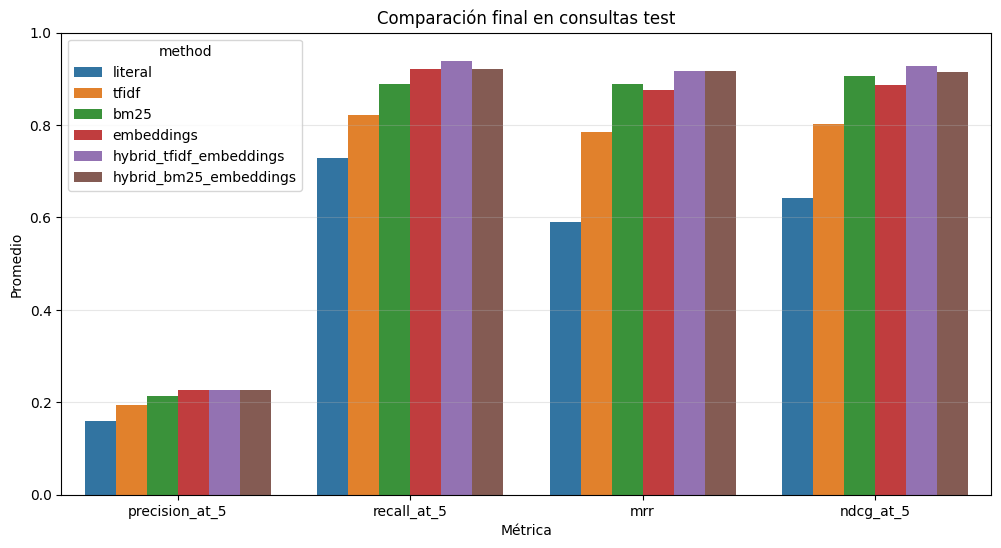

In [18]:
if "evaluation_summary_test" in globals():
    plot_data = evaluation_summary_test.reset_index().melt(
        id_vars="method",
        var_name="metric",
        value_name="value",
    )
    plot_data["method"] = pd.Categorical(
        plot_data["method"],
        categories=METHOD_ORDER,
        ordered=True,
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=plot_data,
        x="metric",
        y="value",
        hue="method",
        hue_order=METHOD_ORDER,
    )
    plt.ylim(0, 1)
    plt.title("Comparación final en consultas test")
    plt.ylabel("Promedio")
    plt.xlabel("Métrica")
    plt.grid(axis="y", alpha=0.3)
    plt.show()
else:
    print("Ejecuta primero la evaluación separada dev/test.")


## 5.4 Análisis estratificado por tipo de consulta

Además del promedio global, se calculan las métricas de `test` por `query_type`: `title`, `content` y `mixed`. Esto permite comprobar si un método gana de forma equilibrada o si su resultado depende de un solo tipo de consulta.


In [19]:
CATEGORY_ORDER = ["title", "content", "mixed"]

if "evaluation_detail" not in globals():
    raise RuntimeError("Ejecuta primero la evaluación final para crear evaluation_detail.")
if "query_type" not in evaluation_queries.columns:
    raise ValueError("evaluation_queries.csv debe incluir la columna query_type.")

query_types = evaluation_queries[["query_id", "query_type"]].drop_duplicates("query_id")
evaluation_detail_by_type = evaluation_detail.merge(
    query_types,
    on="query_id",
    how="left",
    validate="many_to_one",
)

if evaluation_detail_by_type["query_type"].isna().any():
    missing_ids = sorted(
        evaluation_detail_by_type.loc[
            evaluation_detail_by_type["query_type"].isna(), "query_id"
        ].unique()
    )
    raise ValueError(f"Consultas sin query_type: {missing_ids}")

evaluation_summary_test_by_type = (
    evaluation_detail_by_type[
        evaluation_detail_by_type["split"] == "test"
    ]
    .groupby(["query_type", "method"], sort=False)[METRIC_COLUMNS]
    .mean()
    .reset_index()
)
evaluation_summary_test_by_type["query_type"] = pd.Categorical(
    evaluation_summary_test_by_type["query_type"],
    categories=CATEGORY_ORDER,
    ordered=True,
)
evaluation_summary_test_by_type["method"] = pd.Categorical(
    evaluation_summary_test_by_type["method"],
    categories=[
        method for method in METHOD_ORDER
        if method in evaluation_summary_test_by_type["method"].unique()
    ],
    ordered=True,
)
evaluation_summary_test_by_type = evaluation_summary_test_by_type.sort_values(
    ["query_type", "method"]
).reset_index(drop=True)

display(evaluation_summary_test_by_type)

category_winners = evaluation_summary_test_by_type.loc[
    evaluation_summary_test_by_type.groupby("query_type", observed=True)["ndcg_at_5"].idxmax(),
    [
        "query_type",
        "method",
        "precision_at_5",
        "recall_at_5",
        "mrr",
        "ndcg_at_5",
    ],
].sort_values("query_type")

print("Ganador por nDCG@5 en cada tipo de consulta:")
display(category_winners)


,query_type,method,precision_at_5,recall_at_5,mrr,ndcg_at_5
0,title,literal,0.16,0.800000,0.608333,0.656161
1,title,tfidf,0.22,1.000000,0.920000,0.923720
2,title,bm25,0.22,1.000000,0.883333,0.917470
3,title,embeddings,0.22,1.000000,1.000000,0.991972
4,title,hybrid_tfidf_embeddings,0.22,1.000000,1.000000,0.991972
5,title,hybrid_bm25_embeddings,0.22,1.000000,0.950000,0.955065
6,content,literal,0.16,0.700000,0.558333,0.619254
7,content,tfidf,0.18,0.750000,0.750000,0.769343
8,content,bm25,0.20,0.850000,0.900000,0.900000
9,content,embeddings,0.20,0.850000,0.750000,0.774313


Ganador por nDCG@5 en cada tipo de consulta:


,query_type,method,precision_at_5,recall_at_5,mrr,ndcg_at_5
3,title,embeddings,0.22,1.000000,1.00,0.991972
10,content,hybrid_tfidf_embeddings,0.22,0.950000,0.95,0.948127
17,mixed,hybrid_bm25_embeddings,0.26,0.916667,0.95,0.927821


### 5.4.1 Gráfico de calidad por tipo de consulta

La figura mantiene las métricas separadas y permite comparar los tres tipos de consulta sin mezclarlos en un único promedio.


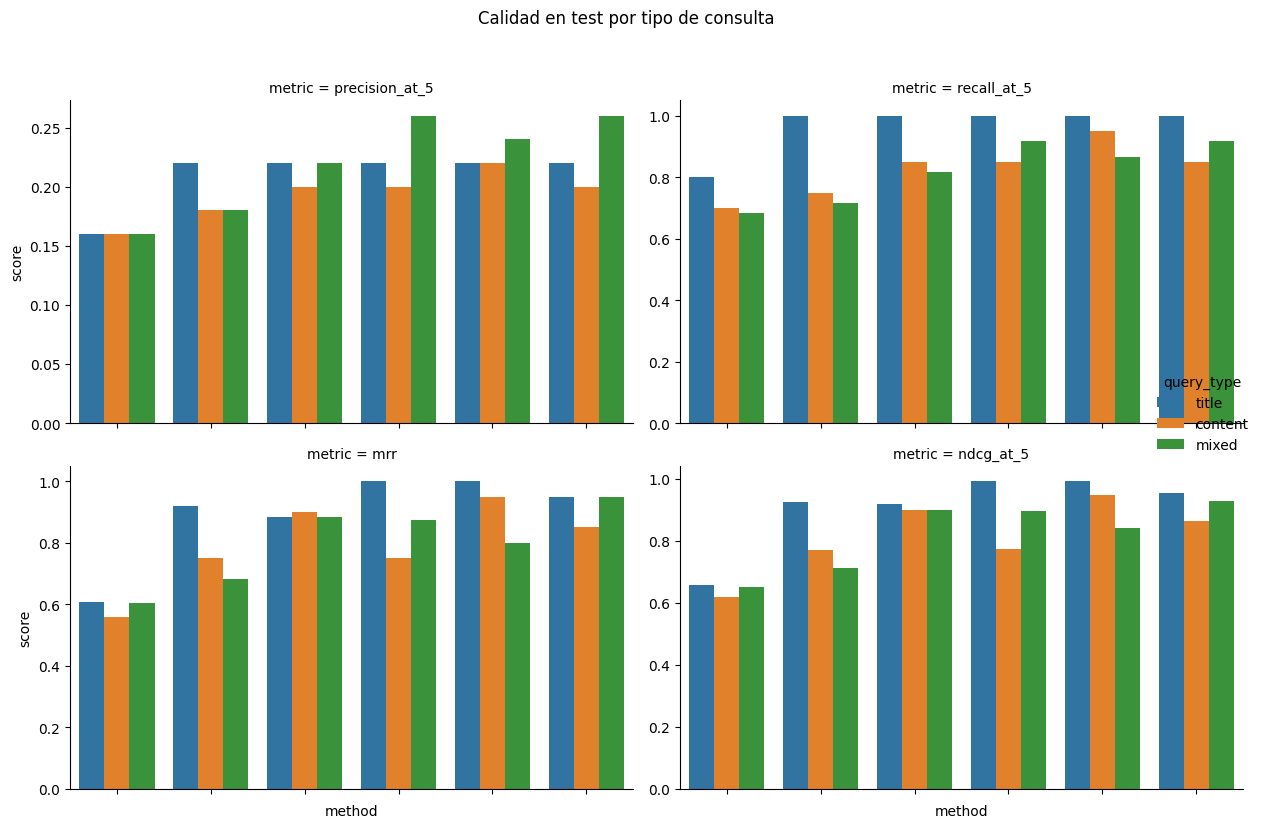

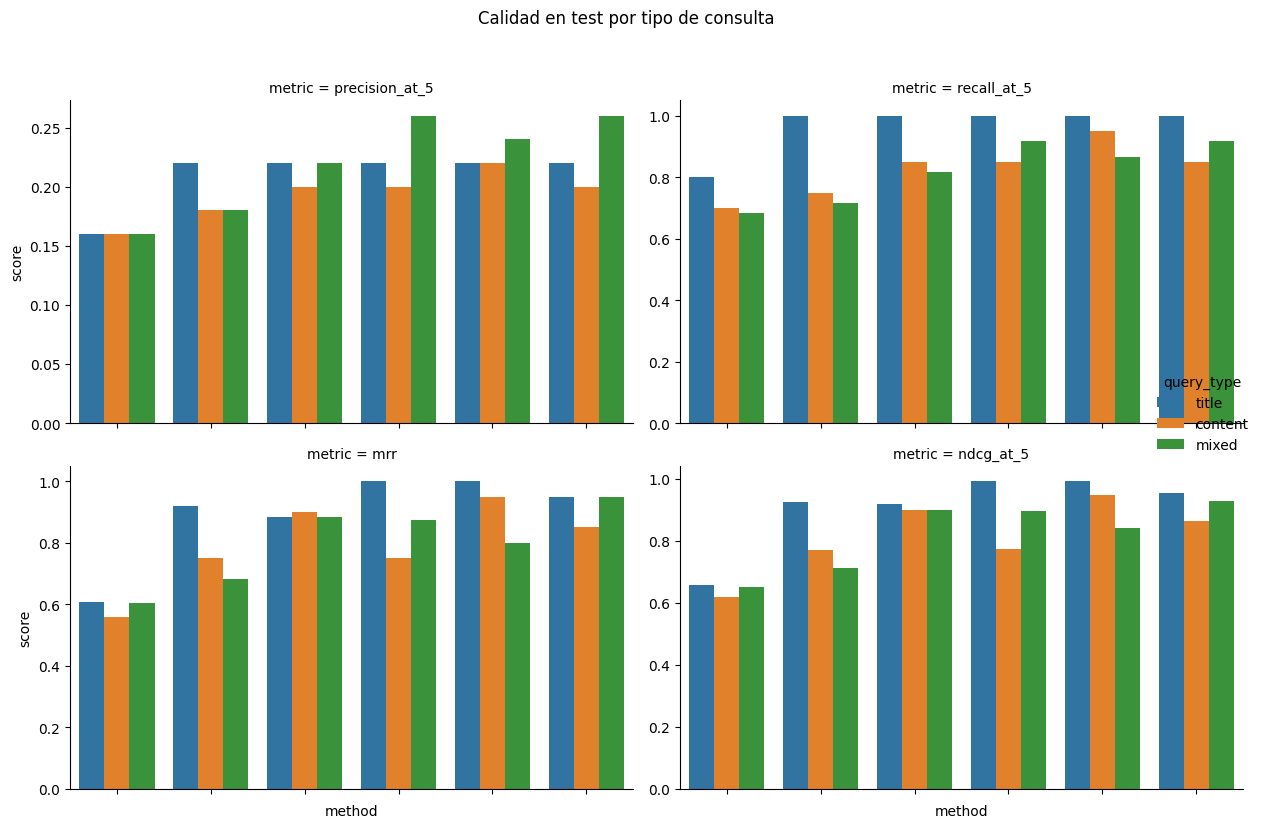

In [20]:
CATEGORY_EVIDENCE_DIR = LOCAL_ROOT / "evaluation"
CATEGORY_EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)

quality_by_type_long = evaluation_summary_test_by_type.melt(
    id_vars=["query_type", "method"],
    value_vars=METRIC_COLUMNS,
    var_name="metric",
    value_name="score",
)
quality_by_type_long["method"] = quality_by_type_long["method"].astype(str)
quality_by_type_long["query_type"] = quality_by_type_long["query_type"].astype(str)

category_figure = sns.catplot(
    data=quality_by_type_long,
    x="method",
    y="score",
    hue="query_type",
    col="metric",
    col_wrap=2,
    kind="bar",
    order=[method for method in METHOD_ORDER if method in quality_by_type_long["method"].unique()],
    col_order=METRIC_COLUMNS,
    height=4,
    aspect=1.45,
    sharey=False,
)
category_figure.set_xticklabels(rotation=35, ha="right")
category_figure.figure.suptitle(
    "Calidad en test por tipo de consulta",
    y=1.03,
)
category_figure.figure.tight_layout()
category_figure.figure.savefig(
    CATEGORY_EVIDENCE_DIR / "quality_by_query_type_test.png",
    dpi=180,
    bbox_inches="tight",
)
display(category_figure.figure)


## 5.5 Revisión manual de consultas `content` y `mixed`

La columna `relevant_documents` contiene una primera propuesta de relevancia. Antes de usar estas métricas en la tesis, revisa cada fila `content` y `mixed` leyendo el título, resumen o texto del PDF. Conserva solo los documentos que realmente respondan a la consulta y agrega los que falten usando exactamente su `document_path`.

Esta revisión puede modificar las etiquetas, pero no debe utilizar las consultas `test` para ajustar `alpha` ni para cambiar el algoritmo antes de la comparación final.


In [21]:
queries_for_review = (
    evaluation_queries[
        evaluation_queries["query_type"].isin(["content", "mixed"])
    ]
    .sort_values(["query_type", "split", "query_id"])
    .copy()
)

review_columns = [
    "query_id",
    "query",
    "query_type",
    "split",
    "relevant_documents",
]
display(queries_for_review[review_columns])

queries_for_review.to_csv(
    CATEGORY_EVIDENCE_DIR / "queries_content_mixed_for_review.csv",
    index=False,
)
print(
    "Se exportó una copia para revisión en:",
    CATEGORY_EVIDENCE_DIR / "queries_content_mixed_for_review.csv",
)


def inspect_query_documents(query_id, max_chars=800):
    """Muestra el texto inicial de los documentos relevantes de una consulta."""
    selected = evaluation_queries[
        evaluation_queries["query_id"] == query_id
    ]
    if selected.empty:
        raise ValueError(f"No existe query_id={query_id}.")

    row = selected.iloc[0]
    print(f"{row['query_id']} — {row['query']} ({row['query_type']}, {row['split']})")
    for document_path in parse_relevant_documents(row["relevant_documents"]):
        matches = documents[documents["document_path"] == document_path]
        print(f"\n--- {document_path} ---")
        if matches.empty:
            print("No se encontró la ruta en documents.")
            continue
        document = matches.iloc[0]
        print("Título:", document.get("document_title", ""))
        print(str(document.get("text_content", ""))[:max_chars])

print(
    "Para revisar una consulta concreta, ejecuta por ejemplo "
    "inspect_query_documents('q024')."
)


,query_id,query,query_type,split,relevant_documents
20,q021,desigualdad educativa,content,dev,2+Un+nuevo+Escenario+Educativo.pdf|6+Es+como+s...
21,q022,acceso a la universidad pública,content,dev,Retos+de+la+universidad+pública+.pdf
22,q023,identidad y educación,content,dev,Des-colonialidades+en+los+procesos+de++identif...
23,q024,dependencia y sustitución del trabajo humano a...,content,dev,"1+El+que+tiene+que+pensar+soy+yo,+no+la+comput..."
24,q025,qué método mixto se utilizó para conocer las o...,content,dev,6.pdf
25,q026,métodos de trabajo comunitario aprendidos dura...,content,dev,"2._La+ley+es+diferente+aquí+arriba,+abajo+todo..."
26,q027,reformas universitarias que articulen investig...,content,dev,Pensar+para+actuar+Un+diálogo+académico+sobre+...
27,q028,factores que explican el abandono o continuida...,content,dev,6+Es+como+ser+doble+persona;+estudiante+y+madr...
28,q029,estrategias de producción sostenible de instru...,content,dev,7.pdf
29,q030,efectos de la migración juvenil sobre la trans...,content,dev,3+IDENTIDADES+5+Olguina+Amaya+y+Daniela+Santa+...


Se exportó una copia para revisión en: /content/eduhamuy-search-artifacts/2026-10-07-v1/evaluation/queries_content_mixed_for_review.csv
Para revisar una consulta concreta, ejecuta por ejemplo inspect_query_documents('q024').


# 6. Guardar artefactos versionados

Cada método guarda sus artefactos bajo una versión del corpus. La carpeta experimental se mantiene separada de los artefactos activos que consume el backend.

- Literal: texto procesado, metadatos, configuración e informe de extracción.
- TF-IDF: `tfidf_vectorizer.joblib`, `X_tfidf.npz` y metadatos.
- BM25: índice serializado, tokens y metadatos.
- Embeddings: matriz de vectores, configuración del modelo y metadatos.
- `hybrid_tfidf_embeddings`: configuración, `alpha` y referencias a TF-IDF y embeddings.
- `hybrid_bm25_embeddings`: configuración, `alpha` y referencias a BM25 y embeddings.
- Evaluación: consultas, detalle por consulta y resumen de métricas cuando existen anotaciones.
- Manifiesto: tamaños y hashes SHA-256 para identificar exactamente la versión.


La persistencia se ejecuta después de la evaluación para registrar los pesos `alpha`, las tablas de resultados y el contrato asociado a la versión aprobada.

In [22]:
METHOD_DIRS = {
    "literal": LOCAL_ROOT / "literal",
    "tfidf": LOCAL_ROOT / "tfidf",
    "bm25": LOCAL_ROOT / "bm25",
    "embeddings": LOCAL_ROOT / "embeddings",
    "hybrid_tfidf_embeddings": LOCAL_ROOT / "hybrid_tfidf_embeddings",
    "hybrid_bm25_embeddings": LOCAL_ROOT / "hybrid_bm25_embeddings",
    "evaluation": LOCAL_ROOT / "evaluation",
}

for directory in METHOD_DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

document_metadata = documents[
    ["document_path", "document_title", "document_words"]
].copy()

documents.to_csv(METHOD_DIRS["literal"] / "processed_documents.csv", index=False)
document_metadata.to_csv(METHOD_DIRS["literal"] / "document_metadata.csv", index=False)
with open(METHOD_DIRS["literal"] / "extraction_report.json", "w", encoding="utf-8") as file:
    json.dump({
        "pdfs_without_extractable_text": skipped_no_text,
        "pdfs_with_errors": skipped_errors,
        "document_count": int(len(documents)),
    }, file, ensure_ascii=False, indent=2)
with open(METHOD_DIRS["literal"] / "literal_config.json", "w", encoding="utf-8") as file:
    json.dump({
        "method": "literal",
        "phrase_bonus": 0.25,
        "normalization": "same_as_preprocess_text",
        "corpus_version": CORPUS_VERSION,
    }, file, ensure_ascii=False, indent=2)

joblib.dump(tfidf_vectorizer, METHOD_DIRS["tfidf"] / "tfidf_vectorizer.joblib")
scipy.sparse.save_npz(METHOD_DIRS["tfidf"] / "X_tfidf.npz", X_tfidf)
document_metadata.to_csv(METHOD_DIRS["tfidf"] / "document_metadata.csv", index=False)

joblib.dump(bm25, METHOD_DIRS["bm25"] / "bm25_index.joblib")
with open(METHOD_DIRS["bm25"] / "tokenized_documents.json", "w", encoding="utf-8") as file:
    json.dump(documents["tokens"].tolist(), file, ensure_ascii=False)
document_metadata.to_csv(METHOD_DIRS["bm25"] / "document_metadata.csv", index=False)

if document_embeddings is not None:
    np.save(METHOD_DIRS["embeddings"] / "document_embeddings.npy", document_embeddings)
    document_metadata.to_csv(METHOD_DIRS["embeddings"] / "document_metadata.csv", index=False)
    with open(METHOD_DIRS["embeddings"] / "embedding_config.json", "w", encoding="utf-8") as file:
        json.dump({
            "model_name": EMBEDDING_MODEL_NAME,
            "normalize_embeddings": True,
            "document_representation": "title_plus_full_text",
            "corpus_version": CORPUS_VERSION,
        }, file, ensure_ascii=False, indent=2)

HYBRID_CONFIGS = {
    "hybrid_tfidf_embeddings": {
        "lexical_method": "tfidf",
        "lexical_artifacts": [
            "../tfidf/tfidf_vectorizer.joblib",
            "../tfidf/X_tfidf.npz",
        ],
    },
    "hybrid_bm25_embeddings": {
        "lexical_method": "bm25",
        "lexical_artifacts": [
            "../bm25/bm25_index.joblib",
            "../bm25/tokenized_documents.json",
        ],
    },
}
for method, settings in HYBRID_CONFIGS.items():
    with open(METHOD_DIRS[method] / "hybrid_config.json", "w", encoding="utf-8") as file:
        json.dump({
            "method": method,
            "lexical_method": settings["lexical_method"],
            "semantic_method": EMBEDDING_MODEL_NAME,
            "alpha": globals().get("HYBRID_ALPHA_USED", {}).get(method, 0.5),
            "normalization": "minmax",
            "lexical_artifacts": settings["lexical_artifacts"],
            "embedding_artifacts": [
                "../embeddings/document_embeddings.npy",
                "../embeddings/embedding_config.json",
            ],
            "corpus_version": CORPUS_VERSION,
        }, file, ensure_ascii=False, indent=2)

evaluation_queries.to_csv(METHOD_DIRS["evaluation"] / "evaluation_queries.csv", index=False)
if "evaluation_detail" in globals():
    evaluation_detail.to_csv(METHOD_DIRS["evaluation"] / "evaluation_detail.csv", index=False)
if "evaluation_summary" in globals():
    evaluation_summary.to_csv(METHOD_DIRS["evaluation"] / "evaluation_summary.csv")

print(f"Artefactos guardados en {LOCAL_ROOT}")
for method, directory in METHOD_DIRS.items():
    print(method, "→", len(list(directory.iterdir())), "archivos")


Artefactos guardados en /content/eduhamuy-search-artifacts/2026-10-07-v1
literal → 4 archivos
tfidf → 3 archivos
bm25 → 3 archivos
embeddings → 3 archivos
hybrid_tfidf_embeddings → 1 archivos
hybrid_bm25_embeddings → 1 archivos
evaluation → 5 archivos


In [23]:
def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def write_artifact_manifest():
    manifest_path = LOCAL_ROOT / "artifact_manifest.json"
    manifest = {
        "target_env": TARGET_ENV,
        "corpus_version": CORPUS_VERSION,
        "suite_version": SUITE_VERSION,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "document_count": int(len(documents)),
        "selected_method": globals().get("SELECTED_METHOD"),
        "files": {},
    }

    for path in sorted(LOCAL_ROOT.rglob("*")):
        if path.is_file() and path != manifest_path:
            manifest["files"][path.relative_to(LOCAL_ROOT).as_posix()] = {
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }

    with manifest_path.open("w", encoding="utf-8") as file:
        json.dump(manifest, file, ensure_ascii=False, indent=2)
    return manifest_path

print("Función para crear el manifiesto de artefactos preparada.")


Función para crear el manifiesto de artefactos preparada.


# 7. Benchmark operativo de construcción, consulta, memoria y almacenamiento

Esta sección mide los costos relativos de los métodos con el mismo corpus y las mismas consultas. Se registran:

- tiempo de construcción del índice;
- memoria incremental observada durante la construcción;
- latencia media, mediana y p95 de consulta;
- tamaño directo de los artefactos;
- tamaño efectivo cuando un método reutiliza artefactos de otros métodos.

El costo monetario exacto no se infiere desde Colab: depende de la tarifa de Azure, el SKU de AKS, el almacenamiento y el tiempo de ejecución. Por eso se reportan también proxies operativos: segundos de construcción, segundos por cada 1.000 consultas y megabytes almacenados.

La memoria de embeddings se mide con el modelo ya cargado, por lo que no incluye completamente el peso inicial del modelo.


In [24]:
import gc
import time

try:
    import psutil
except ImportError:
    psutil = None

BENCHMARK_REPEATS = 3
BENCHMARK_TOP_N = 5
BENCHMARK_QUERIES = (
    evaluation_queries["query"]
    .dropna()
    .astype(str)
    .loc[lambda values: values.str.strip() != ""]
    .tolist()
)


def process_rss_mb():
    if psutil is None:
        return np.nan
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)


def build_literal_benchmark():
    # Representación mínima que se conserva para la línea base literal.
    return documents[["document_path", "document_title", "cleaned_text"]].copy()


def build_tfidf_benchmark():
    vectorizer = TfidfVectorizer()
    matrix = vectorizer.fit_transform(documents["cleaned_text"])
    return vectorizer, matrix


def build_bm25_benchmark():
    return BM25Okapi(documents["tokens"].tolist())


def build_embeddings_benchmark():
    if embedding_model is None:
        return None
    texts = (
        documents["document_title"].fillna("")
        + ". "
        + documents["text_content"].fillna("")
    ).tolist()
    return np.asarray(
        embedding_model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
        )
    )


BUILDERS = {
    "literal": build_literal_benchmark,
    "tfidf": build_tfidf_benchmark,
    "bm25": build_bm25_benchmark,
}
if embedding_model is not None:
    BUILDERS["embeddings"] = build_embeddings_benchmark

build_records = []
for method, builder in BUILDERS.items():
    gc.collect()
    before_memory = process_rss_mb()
    start = time.perf_counter()
    built_object = builder()
    elapsed = time.perf_counter() - start
    after_memory = process_rss_mb()
    build_records.append({
        "method": method,
        "build_seconds": elapsed,
        "build_memory_delta_mb": (
            max(0.0, after_memory - before_memory)
            if not np.isnan(before_memory) and not np.isnan(after_memory)
            else np.nan
        ),
    })
    del built_object
    gc.collect()

# Cada híbrido reutiliza solo los dos índices que combina.
build_by_method = {row["method"]: row["build_seconds"] for row in build_records}
for method, components in {
    "hybrid_tfidf_embeddings": ["tfidf", "embeddings"],
    "hybrid_bm25_embeddings": ["bm25", "embeddings"],
}.items():
    if all(component in build_by_method for component in components):
        build_records.append({
            "method": method,
            "build_seconds": sum(build_by_method[component] for component in components),
            "build_memory_delta_mb": np.nan,
        })


def measure_query_latency(method, searcher):
    # Calentamiento para no mezclar la primera llamada con importaciones/cache.
    for query in BENCHMARK_QUERIES:
        searcher(query, BENCHMARK_TOP_N)

    samples_ms = []
    for _ in range(BENCHMARK_REPEATS):
        for query in BENCHMARK_QUERIES:
            start = time.perf_counter()
            searcher(query, BENCHMARK_TOP_N)
            samples_ms.append((time.perf_counter() - start) * 1000)

    return {
        "method": method,
        "query_count": len(BENCHMARK_QUERIES),
        "query_repeats": BENCHMARK_REPEATS,
        "mean_query_ms": float(np.mean(samples_ms)),
        "median_query_ms": float(np.median(samples_ms)),
        "p95_query_ms": float(np.percentile(samples_ms, 95)),
        "query_wall_seconds_per_1000": float(np.mean(samples_ms)),
    }

latency_records = [
    measure_query_latency(method, searcher)
    for method, searcher in SEARCHERS.items()
]


def directory_bytes(directory):
    return sum(path.stat().st_size for path in directory.rglob("*") if path.is_file())


METHOD_ARTIFACTS = [
    "literal",
    "tfidf",
    "bm25",
    "embeddings",
    "hybrid_tfidf_embeddings",
    "hybrid_bm25_embeddings",
]
direct_sizes = {
    method: directory_bytes(METHOD_DIRS[method])
    for method in METHOD_ARTIFACTS
}
effective_sizes = dict(direct_sizes)
for method, components in {
    "hybrid_tfidf_embeddings": ["tfidf", "embeddings"],
    "hybrid_bm25_embeddings": ["bm25", "embeddings"],
}.items():
    effective_sizes[method] = direct_sizes[method] + sum(
        direct_sizes[component] for component in components
    )

benchmark = pd.DataFrame(build_records).merge(
    pd.DataFrame(latency_records),
    on="method",
    how="outer",
)
benchmark["artifact_size_mb"] = benchmark["method"].map(
    lambda method: direct_sizes.get(method, 0) / (1024 ** 2)
)
benchmark["effective_artifact_size_mb"] = benchmark["method"].map(
    lambda method: effective_sizes.get(method, 0) / (1024 ** 2)
)
benchmark["rebuild_wall_seconds"] = benchmark["build_seconds"]
benchmark["storage_gb"] = benchmark["effective_artifact_size_mb"] / 1024

benchmark = benchmark.sort_values(
    "method",
    key=lambda values: values.map({method: index for index, method in enumerate(METHOD_ORDER)}),
).reset_index(drop=True)

print("Benchmark operativo; los costos monetarios requieren tarifas externas.")
display(benchmark[[
    "method",
    "build_seconds",
    "build_memory_delta_mb",
    "mean_query_ms",
    "median_query_ms",
    "p95_query_ms",
    "artifact_size_mb",
    "effective_artifact_size_mb",
    "query_wall_seconds_per_1000",
]])


Benchmark operativo; los costos monetarios requieren tarifas externas.


,method,build_seconds,build_memory_delta_mb,mean_query_ms,median_query_ms,p95_query_ms,artifact_size_mb,effective_artifact_size_mb,query_wall_seconds_per_1000
0,literal,0.000594,0.000000,77.429973,77.358159,78.461631,29.899962,29.899962,77.429973
1,tfidf,0.386145,2.902344,1.968608,1.966574,1.991517,3.091859,3.091859,1.968608
2,bm25,0.113387,0.000000,0.435020,0.434985,0.524297,15.576662,15.576662,0.435020
3,embeddings,0.636198,253.367188,3.666064,3.653698,3.817677,0.338779,0.338779,3.666064
4,hybrid_tfidf_embeddings,1.022343,NaN,5.604519,5.596218,5.750687,0.000446,3.431085,5.604519
5,hybrid_bm25_embeddings,0.749585,NaN,4.050957,4.040964,4.233991,0.000434,15.915875,4.050957


## 7.1 Gráficos separados del benchmark operativo

El gráfico de calidad en `test` se genera en la sección anterior y muestra `Precision@5`, `Recall@5`, `MRR` y `nDCG@5`. Las siguientes figuras mantienen separadas las unidades del benchmark:

- tiempo de construcción;
- latencia media, mediana y p95;
- tamaño directo y efectivo de artefactos;
- memoria incremental, únicamente cuando la medición es informativa.

También se genera una figura resumen de cuatro paneles para facilitar la comparación visual. No se mezclan las unidades en un mismo eje.


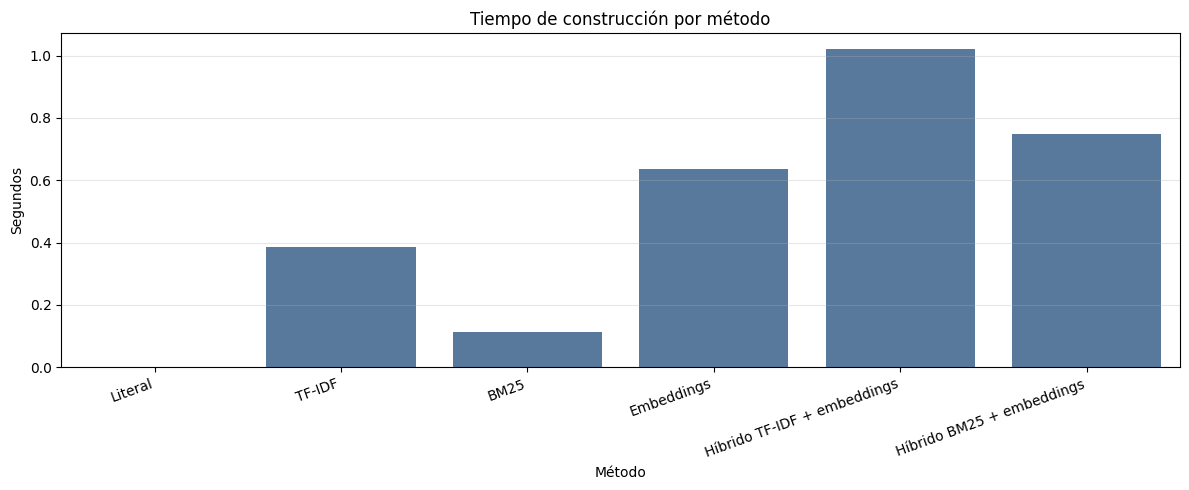

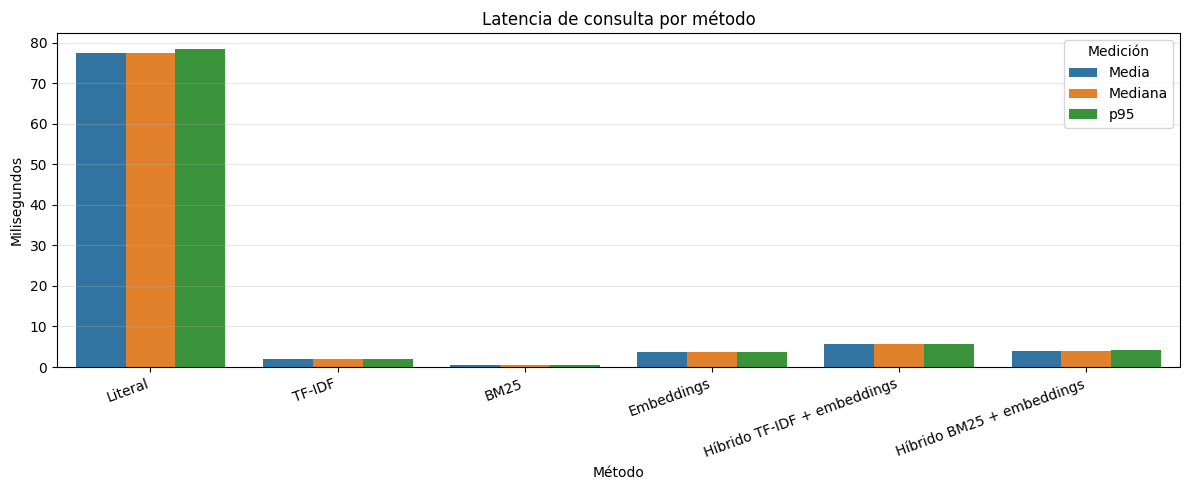

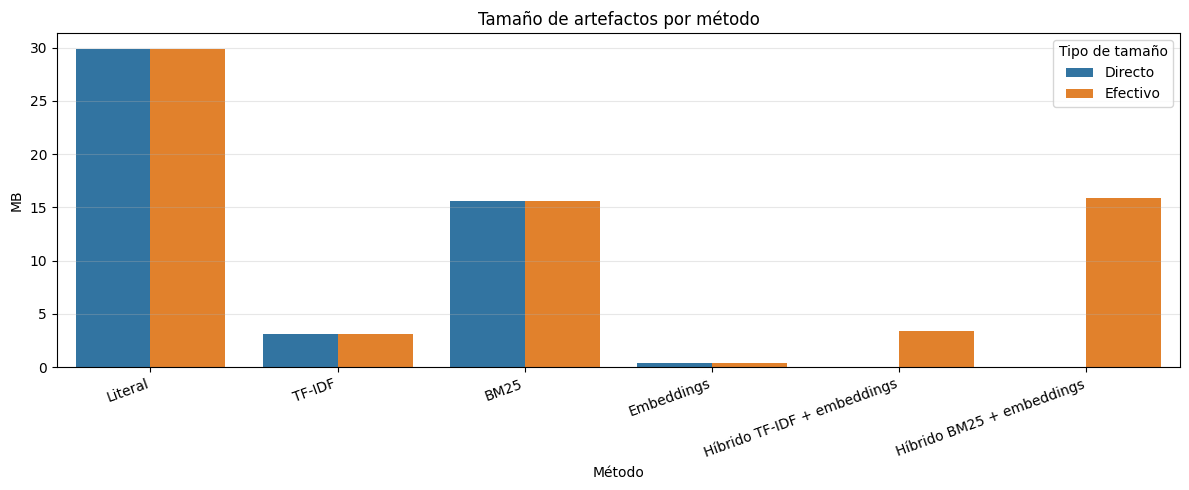

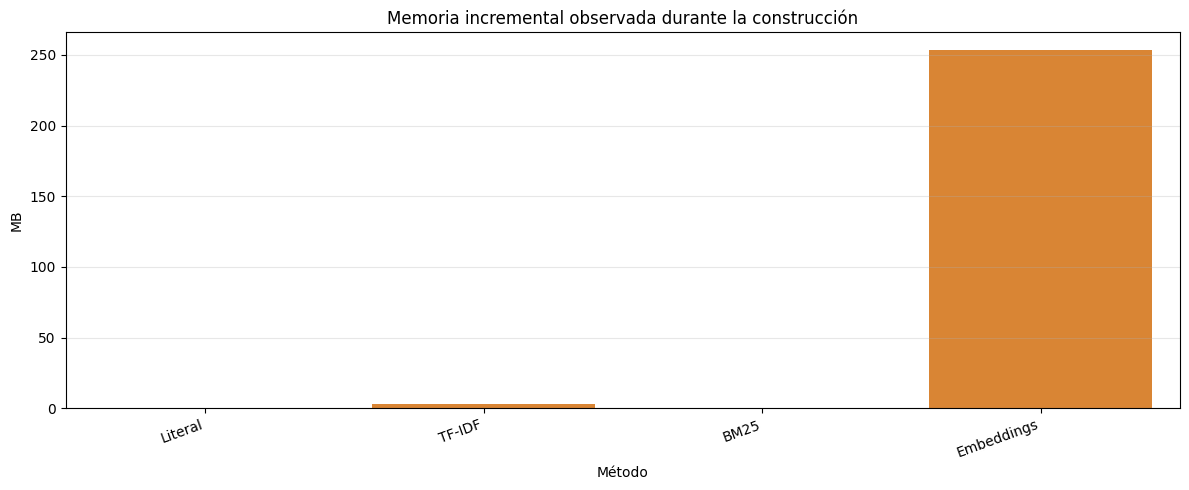

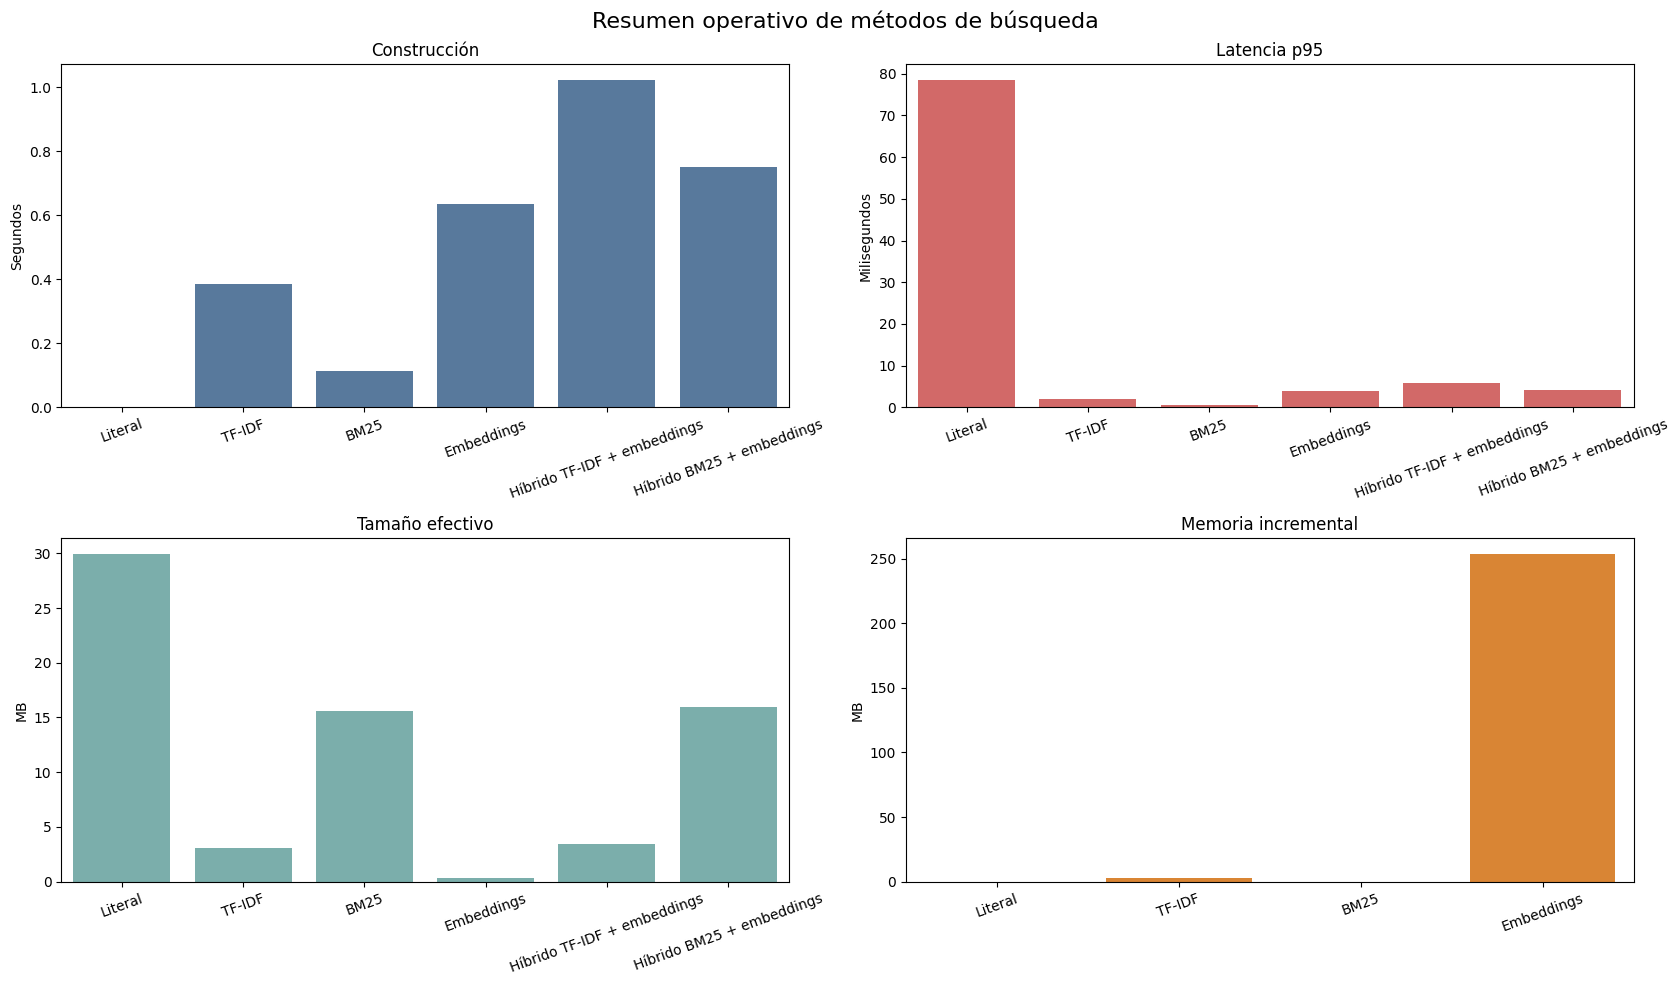

In [25]:
BENCHMARK_METHOD_ORDER = [
    method for method in METHOD_ORDER if method in benchmark["method"].tolist()
]
METHOD_LABELS = {
    "literal": "Literal",
    "tfidf": "TF-IDF",
    "bm25": "BM25",
    "embeddings": "Embeddings",
    "hybrid_tfidf_embeddings": "Híbrido TF-IDF + embeddings",
    "hybrid_bm25_embeddings": "Híbrido BM25 + embeddings",
}

benchmark_plot = benchmark.copy()
benchmark_plot["method"] = pd.Categorical(
    benchmark_plot["method"],
    categories=BENCHMARK_METHOD_ORDER,
    ordered=True,
)
benchmark_plot["label"] = benchmark_plot["method"].astype(str).map(METHOD_LABELS)
benchmark_plot = benchmark_plot.sort_values("method")
plot_order = [METHOD_LABELS[method] for method in BENCHMARK_METHOD_ORDER]

# 1. Tiempo de construcción.
plt.figure(figsize=(12, 5))
sns.barplot(
    data=benchmark_plot,
    x="label",
    y="build_seconds",
    order=plot_order,
    color="#4C78A8",
)
plt.title("Tiempo de construcción por método")
plt.xlabel("Método")
plt.ylabel("Segundos")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Latencia media, mediana y p95.
latency_plot = benchmark_plot.melt(
    id_vars="label",
    value_vars=["mean_query_ms", "median_query_ms", "p95_query_ms"],
    var_name="measure",
    value_name="milliseconds",
)
latency_labels = {
    "mean_query_ms": "Media",
    "median_query_ms": "Mediana",
    "p95_query_ms": "p95",
}
latency_plot["measure"] = latency_plot["measure"].map(latency_labels)
plt.figure(figsize=(12, 5))
sns.barplot(
    data=latency_plot,
    x="label",
    y="milliseconds",
    hue="measure",
    order=plot_order,
)
plt.title("Latencia de consulta por método")
plt.xlabel("Método")
plt.ylabel("Milisegundos")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Medición")
plt.tight_layout()
plt.show()

# 3. Tamaño directo y efectivo de artefactos.
size_plot = benchmark_plot.melt(
    id_vars="label",
    value_vars=["artifact_size_mb", "effective_artifact_size_mb"],
    var_name="size_type",
    value_name="megabytes",
)
size_labels = {
    "artifact_size_mb": "Directo",
    "effective_artifact_size_mb": "Efectivo",
}
size_plot["size_type"] = size_plot["size_type"].map(size_labels)
plt.figure(figsize=(12, 5))
sns.barplot(
    data=size_plot,
    x="label",
    y="megabytes",
    hue="size_type",
    order=plot_order,
)
plt.title("Tamaño de artefactos por método")
plt.xlabel("Método")
plt.ylabel("MB")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Tipo de tamaño")
plt.tight_layout()
plt.show()

# 4. Memoria incremental. Una medición plana o ausente no se interpreta.
memory_plot = benchmark_plot.dropna(subset=["build_memory_delta_mb"])
if not memory_plot.empty and memory_plot["build_memory_delta_mb"].max() > 0:
    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=memory_plot,
        x="label",
        y="build_memory_delta_mb",
        order=[label for label in plot_order if label in memory_plot["label"].tolist()],
        color="#F58518",
    )
    plt.title("Memoria incremental observada durante la construcción")
    plt.xlabel("Método")
    plt.ylabel("MB")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(
        "Memoria: no se genera un gráfico porque la medición incremental es "
        "cero o no está disponible. Ejecuta mediciones aisladas por proceso "
        "antes de interpretar este recurso."
    )

# 5. Figura resumen: las métricas conservan ejes independientes.
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

sns.barplot(
    data=benchmark_plot,
    x="label",
    y="build_seconds",
    order=plot_order,
    color="#4C78A8",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Construcción")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Segundos")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=benchmark_plot,
    x="label",
    y="p95_query_ms",
    order=plot_order,
    color="#E45756",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Latencia p95")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Milisegundos")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.barplot(
    data=benchmark_plot,
    x="label",
    y="effective_artifact_size_mb",
    order=plot_order,
    color="#72B7B2",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Tamaño efectivo")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("MB")
axes[1, 0].tick_params(axis="x", rotation=20)

if not memory_plot.empty and memory_plot["build_memory_delta_mb"].max() > 0:
    sns.barplot(
        data=memory_plot,
        x="label",
        y="build_memory_delta_mb",
        order=[label for label in plot_order if label in memory_plot["label"].tolist()],
        color="#F58518",
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("Memoria incremental")
    axes[1, 1].set_ylabel("MB")
else:
    axes[1, 1].text(
        0.5,
        0.5,
        "Medición no informativa\n(requiere procesos aislados)",
        ha="center",
        va="center",
    )
    axes[1, 1].set_title("Memoria incremental")
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=20)

fig.suptitle("Resumen operativo de métodos de búsqueda", fontsize=16)
fig.tight_layout()
plt.show()


### 7.2 Figura resumen del benchmark operativo

Se conserva una figura de referencia con construcción, latencia p95 y tamaño efectivo. La memoria se mantiene como no concluyente cuando la medición incremental no es informativa.


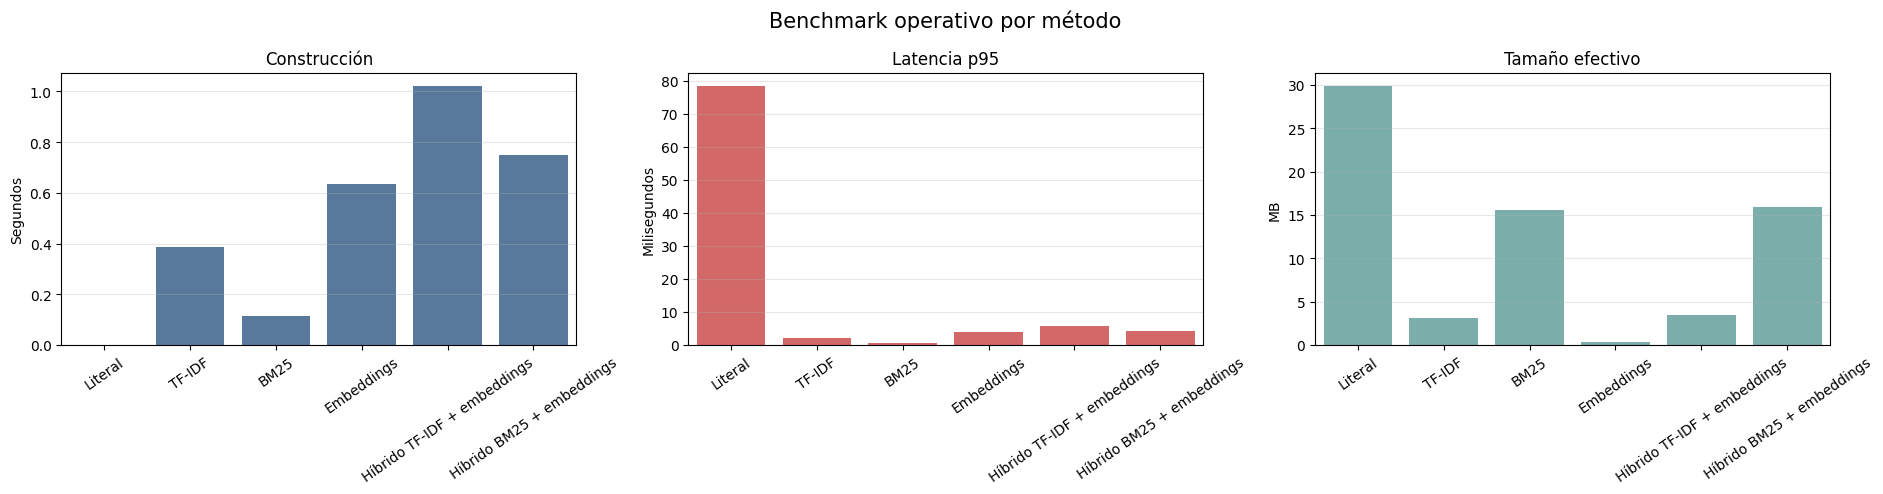

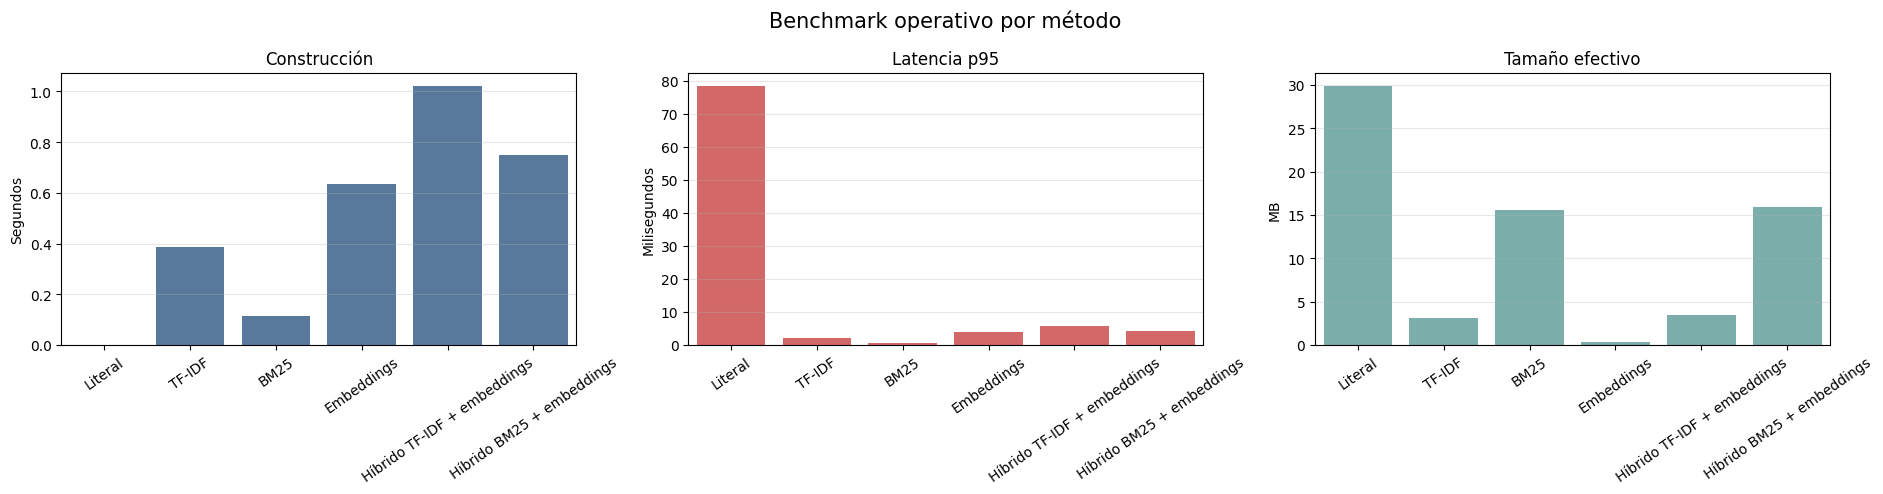

In [26]:
BENCHMARK_EVIDENCE_DIR = LOCAL_ROOT / "evaluation"
BENCHMARK_EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)

benchmark_plot_export = benchmark.copy()
benchmark_plot_export["method"] = benchmark_plot_export["method"].astype(str)
benchmark_plot_export["label"] = benchmark_plot_export["method"].map(METHOD_LABELS)
benchmark_plot_export = benchmark_plot_export.dropna(subset=["label"])
benchmark_export_order = [
    METHOD_LABELS[method]
    for method in METHOD_ORDER
    if method in benchmark_plot_export["method"].tolist()
]

benchmark_figure, benchmark_axes = plt.subplots(1, 3, figsize=(19, 5))
for axis, metric, title, ylabel, color in [
    (benchmark_axes[0], "build_seconds", "Construcción", "Segundos", "#4C78A8"),
    (benchmark_axes[1], "p95_query_ms", "Latencia p95", "Milisegundos", "#E45756"),
    (benchmark_axes[2], "effective_artifact_size_mb", "Tamaño efectivo", "MB", "#72B7B2"),
]:
    sns.barplot(
        data=benchmark_plot_export,
        x="label",
        y=metric,
        order=benchmark_export_order,
        color=color,
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=35)
    axis.grid(axis="y", alpha=0.3)

benchmark_figure.suptitle("Benchmark operativo por método", fontsize=15)
benchmark_figure.tight_layout()
benchmark_figure.savefig(
    BENCHMARK_EVIDENCE_DIR / "benchmark_summary.png",
    dpi=180,
    bbox_inches="tight",
)
display(benchmark_figure)


# 8. Decisión experimental del método final

Esta sección separa dos criterios de decisión:

1. **Calidad en `test`**, medida mediante `Precision@5`, `Recall@5`, `MRR` y `nDCG@5`.
2. **Operación**, medida mediante tiempo de construcción, latencia, memoria observada, tamaño de artefactos y proxies de costo.

La calidad en `test` tiene prioridad para seleccionar el método de búsqueda. El benchmark operativo se utiliza para comprobar que el método ganador sea viable y para documentar sus compromisos. El costo monetario exacto no se calcula porque depende de las tarifas de Azure, el SKU de AKS, el almacenamiento y el patrón real de consultas.

En la ejecución actual, `hybrid_tfidf_embeddings` obtiene el mejor `nDCG@5` y el mejor `MRR` en `test`. Empata en `Precision@5` con `hybrid_bm25_embeddings` y alcanza el mayor `Recall@5`. Por calidad, queda seleccionado como método experimental para la siguiente versión del backend.

El benchmark operativo no produce un ganador único: BM25 es el más rápido en consulta, TF-IDF construye el índice más rápido y embeddings ocupa menos almacenamiento directo. El híbrido seleccionado requiere más tiempo de construcción y consulta que BM25, pero ofrece la mejor calidad observada. Esta decisión no significa que el backend ya haya cambiado; la promoción requiere publicar los artefactos aprobados y actualizar la configuración de despliegue.

In [27]:
QUALITY_PRIMARY_METRIC = "ndcg_at_5"
QUALITY_SECONDARY_METRIC = "mrr"

quality_summary = evaluation_summary_test.reindex(
    [method for method in METHOD_ORDER if method in evaluation_summary_test.index]
).copy()
quality_winner = quality_summary[QUALITY_PRIMARY_METRIC].idxmax()
quality_winner_mrr = quality_summary[QUALITY_SECONDARY_METRIC].idxmax()

operational_summary = benchmark.set_index("method").reindex(
    [method for method in METHOD_ORDER if method in benchmark["method"].tolist()]
)
# La línea literal se conserva como baseline, pero no se considera candidata
# de despliegue al declarar los ganadores operativos.
operational_candidates = operational_summary.drop(index="literal", errors="ignore")
operational_winners = {
    "construccion": operational_candidates["build_seconds"].idxmin(),
    "latencia_media": operational_candidates["mean_query_ms"].idxmin(),
    "latencia_p95": operational_candidates["p95_query_ms"].idxmin(),
    "tamano_efectivo": operational_candidates["effective_artifact_size_mb"].idxmin(),
}

memory_values = operational_candidates["build_memory_delta_mb"].dropna()
positive_memory_values = memory_values[memory_values > 0]
if len(positive_memory_values) >= 2:
    operational_winners["memoria_observada"] = positive_memory_values.idxmin()
else:
    operational_winners["memoria_observada"] = "no concluyente"

METHOD_DECISION = "hybrid_tfidf_embeddings"

print("Ganador por calidad en test:", quality_winner)
print("Ganador por MRR en test:", quality_winner_mrr)
print("Ganadores operativos por dimensión:", operational_winners)
print("Método seleccionado para la siguiente versión:", METHOD_DECISION)

quality_decision_table = quality_summary[
    ["precision_at_5", "recall_at_5", "mrr", "ndcg_at_5"]
].copy()
quality_decision_table["selected_candidate"] = quality_decision_table.index == METHOD_DECISION

display(quality_decision_table)

operational_decision_table = operational_summary[
    [
        "build_seconds",
        "mean_query_ms",
        "p95_query_ms",
        "build_memory_delta_mb",
        "effective_artifact_size_mb",
    ]
].copy()
operational_decision_table["selected_candidate"] = (
    operational_decision_table.index == METHOD_DECISION
)
display(operational_decision_table)


Ganador por calidad en test: hybrid_tfidf_embeddings
Ganador por MRR en test: hybrid_tfidf_embeddings
Ganadores operativos por dimensión: {'construccion': 'bm25', 'latencia_media': 'bm25', 'latencia_p95': 'bm25', 'tamano_efectivo': 'embeddings', 'memoria_observada': 'tfidf'}
Método seleccionado para la siguiente versión: hybrid_tfidf_embeddings


,precision_at_5,recall_at_5,mrr,ndcg_at_5,selected_candidate
method,,,,,
literal,0.160000,0.727778,0.590000,0.642397,False
tfidf,0.193333,0.822222,0.784444,0.802052,False
bm25,0.213333,0.888889,0.888889,0.905199,False
embeddings,0.226667,0.922222,0.875000,0.887547,False
hybrid_tfidf_embeddings,0.226667,0.938889,0.916667,0.927357,True
hybrid_bm25_embeddings,0.226667,0.922222,0.916667,0.915326,False


,build_seconds,mean_query_ms,p95_query_ms,build_memory_delta_mb,effective_artifact_size_mb,selected_candidate
method,,,,,,
literal,0.000594,77.429973,78.461631,0.000000,29.899962,False
tfidf,0.386145,1.968608,1.991517,2.902344,3.091859,False
bm25,0.113387,0.435020,0.524297,0.000000,15.576662,False
embeddings,0.636198,3.666064,3.817677,253.367188,0.338779,False
hybrid_tfidf_embeddings,1.022343,5.604519,5.750687,NaN,3.431085,True
hybrid_bm25_embeddings,0.749585,4.050957,4.233991,NaN,15.915875,False


## 9. Publicación opcional de artefactos en Azure

Al final del notebook se publican todos los resultados bajo `experiments/<corpus_version>/` dentro de `ai-artifacts-dev`. La versión es inmutable: si ese prefijo ya existe, la ejecución se detiene para no sobrescribir evidencia.

La publicación está desactivada por defecto.


In [28]:
# La carga se realiza después de generar toda la evidencia y el manifiesto.
print("La publicación, si se habilita, se ejecutará al final del notebook.")


La publicación, si se habilita, se ejecutará al final del notebook.


# 10. Contrato de despliegue

El notebook no cambia automáticamente el backend. Después de seleccionar un método, este contrato indica qué artefactos debe cargar el servicio.

La evaluación actual selecciona experimentalmente `hybrid_tfidf_embeddings` por calidad en `test`. DEV todavía utiliza TF-IDF en el backend desplegado; por tanto, el contrato generado aquí representa el candidato aprobado para la siguiente promoción, pero no implica que Kubernetes ya esté usando ese método. Para desplegarlo se deben publicar los artefactos versionados, actualizar el contrato, modificar la configuración del servicio y validar el endpoint `/search`.

In [29]:
SELECTED_METHOD = "hybrid_tfidf_embeddings"

DEPLOYMENT_CONTRACTS = {
    "literal": {
        "backend_method": "literal",
        "artifacts": [
            "literal/processed_documents.csv",
            "literal/literal_config.json",
        ],
    },
    "tfidf": {
        "backend_method": "tfidf",
        "artifacts": [
            "tfidf/tfidf_vectorizer.joblib",
            "tfidf/X_tfidf.npz",
            "tfidf/document_metadata.csv",
        ],
    },
    "bm25": {
        "backend_method": "bm25",
        "artifacts": [
            "bm25/bm25_index.joblib",
            "bm25/tokenized_documents.json",
            "bm25/document_metadata.csv",
        ],
    },
    "embeddings": {
        "backend_method": "embeddings",
        "artifacts": [
            "embeddings/document_embeddings.npy",
            "embeddings/embedding_config.json",
            "embeddings/document_metadata.csv",
        ],
    },
    "hybrid_tfidf_embeddings": {
        "backend_method": "hybrid_tfidf_embeddings",
        "artifacts": [
            "tfidf/tfidf_vectorizer.joblib",
            "tfidf/X_tfidf.npz",
            "tfidf/document_metadata.csv",
            "embeddings/document_embeddings.npy",
            "embeddings/embedding_config.json",
            "hybrid_tfidf_embeddings/hybrid_config.json",
        ],
    },
    "hybrid_bm25_embeddings": {
        "backend_method": "hybrid_bm25_embeddings",
        "artifacts": [
            "bm25/bm25_index.joblib",
            "bm25/tokenized_documents.json",
            "embeddings/document_embeddings.npy",
            "embeddings/embedding_config.json",
            "hybrid_bm25_embeddings/hybrid_config.json",
        ],
    },
}

deployment_contract = {
    "corpus_version": CORPUS_VERSION,
    "selected_method": SELECTED_METHOD,
    **DEPLOYMENT_CONTRACTS[SELECTED_METHOD],
}

with open(LOCAL_ROOT / "deployment_contract.json", "w", encoding="utf-8") as file:
    json.dump(deployment_contract, file, ensure_ascii=False, indent=2)

print(json.dumps(deployment_contract, ensure_ascii=False, indent=2))


{
  "corpus_version": "2026-10-07-v1",
  "selected_method": "hybrid_tfidf_embeddings",
  "backend_method": "hybrid_tfidf_embeddings",
  "artifacts": [
    "tfidf/tfidf_vectorizer.joblib",
    "tfidf/X_tfidf.npz",
    "tfidf/document_metadata.csv",
    "embeddings/document_embeddings.npy",
    "embeddings/embedding_config.json",
    "hybrid_tfidf_embeddings/hybrid_config.json"
  ]
}


# 11. Conservar evidencia reproducible

Esta celda guarda las tablas, métricas por categoría, benchmark, pesos de los híbridos y decisión experimental. Al terminar crea `artifact_manifest.json`, que enumera y calcula el hash SHA-256 de cada archivo local que se publicaría; el notebook conserva además las figuras inline.


In [30]:
EVIDENCE_DIR = LOCAL_ROOT / "evaluation"
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)

evaluation_queries.to_csv(
    EVIDENCE_DIR / "evaluation_queries_used.csv",
    index=False,
)
evaluation_detail.to_csv(
    EVIDENCE_DIR / "evaluation_detail.csv",
    index=False,
)
evaluation_detail_by_type.to_csv(
    EVIDENCE_DIR / "evaluation_detail_by_type.csv",
    index=False,
)
evaluation_summary_dev.to_csv(
    EVIDENCE_DIR / "evaluation_summary_dev.csv",
)
evaluation_summary_test.to_csv(
    EVIDENCE_DIR / "evaluation_summary_test.csv",
)
evaluation_summary_test_by_type.to_csv(
    EVIDENCE_DIR / "evaluation_summary_test_by_type.csv",
    index=False,
)
benchmark.to_csv(EVIDENCE_DIR / "benchmark.csv", index=False)
category_winners.to_csv(
    EVIDENCE_DIR / "category_winners.csv",
    index=False,
)

with open(EVIDENCE_DIR / "hybrid_alpha.json", "w", encoding="utf-8") as file:
    json.dump(
        {key: float(value) for key, value in HYBRID_ALPHA_USED.items()},
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(EVIDENCE_DIR / "decision_summary.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "quality_winner": quality_winner,
            "mrr_winner": quality_winner_mrr,
            "selected_method": METHOD_DECISION,
            "winners_by_query_type": category_winners.to_dict(orient="records"),
            "corpus_version": CORPUS_VERSION,
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

if "deployment_contract" in globals():
    with open(EVIDENCE_DIR / "deployment_contract.json", "w", encoding="utf-8") as file:
        json.dump(deployment_contract, file, ensure_ascii=False, indent=2)

artifact_manifest_path = write_artifact_manifest()
ARTIFACT_PREFIX = f"experiments/{CORPUS_VERSION}"

if PUBLISH_ARTIFACTS:
    existing_blobs = list(artifact_container.list_blobs(name_starts_with=f"{ARTIFACT_PREFIX}/"))
    if existing_blobs:
        raise ValueError(
            f"Ya existe una publicación para {ARTIFACT_PREFIX}. "
            "Use una nueva CORPUS_VERSION; no se sobrescribe evidencia."
        )

    for path in sorted(LOCAL_ROOT.rglob("*")):
        if path.is_file():
            blob_name = f"{ARTIFACT_PREFIX}/{path.relative_to(LOCAL_ROOT).as_posix()}"
            with path.open("rb") as data:
                artifact_container.upload_blob(name=blob_name, data=data, overwrite=False)
    print(f"Artefactos experimentales publicados en: {ARTIFACT_PREFIX}")
else:
    print("No se publicaron artefactos en Azure.")

print(f"Evidencia guardada en: {EVIDENCE_DIR}")
print("Manifiesto de artefactos:", artifact_manifest_path)
print("Manifiesto del corpus:", LOCAL_ROOT / "corpus_manifest.json")
print("Manifiesto de la suite:", LOCAL_ROOT / "suite_manifest.json")
print("Contrato de despliegue:", LOCAL_ROOT / "deployment_contract.json")


Artefactos experimentales publicados en: experiments/2026-10-07-v1
Evidencia guardada en: /content/eduhamuy-search-artifacts/2026-10-07-v1/evaluation
Manifiesto de artefactos: /content/eduhamuy-search-artifacts/2026-10-07-v1/artifact_manifest.json
Manifiesto del corpus: /content/eduhamuy-search-artifacts/2026-10-07-v1/corpus_manifest.json
Manifiesto de la suite: /content/eduhamuy-search-artifacts/2026-10-07-v1/suite_manifest.json
Contrato de despliegue: /content/eduhamuy-search-artifacts/2026-10-07-v1/deployment_contract.json


# 12. Resultados

Este notebook cubre las etapas de la tabla: carga desde Blob Storage, extracción y limpieza, construcción de índices, persistencia versionada, recepción y transformación de consultas, cálculo de relevancia, ranking, respuesta, evaluación y preparación del despliegue.

La evaluación actual utiliza 60 consultas anotadas y estratificadas: 20 `title`, 20 `content` y 20 `mixed`. Hay 30 consultas `dev` y 30 `test`, con 10 de cada tipo en cada partición. Las consultas `dev` se usan para ajustar por separado los pesos de los dos híbridos; `test` permanece aislado para la comparación final.

## Resultados de calidad en `test`

En la ejecución actual, los promedios fueron:

| Método | Precision@5 | Recall@5 | MRR | nDCG@5 |
|---|---:|---:|---:|---:|
| Literal | 0.1600 | 0.7278 | 0.5900 | 0.6424 |
| TF-IDF | 0.1933 | 0.8222 | 0.7844 | 0.8021 |
| BM25 | 0.2133 | 0.8889 | 0.8889 | 0.9052 |
| Embeddings | 0.2267 | 0.9222 | 0.8750 | 0.8875 |
| `hybrid_tfidf_embeddings` | **0.2267** | **0.9389** | **0.9167** | **0.9274** |
| `hybrid_bm25_embeddings` | **0.2267** | 0.9222 | **0.9167** | 0.9153 |

El ganador por `nDCG@5` y por `MRR` es `hybrid_tfidf_embeddings`. Los dos híbridos empatan en `Precision@5` y `MRR`, pero el híbrido TF-IDF obtiene mejor `Recall@5` y `nDCG@5`. Por tanto, se selecciona `hybrid_tfidf_embeddings` como candidato final por calidad, sujeto a la revisión manual de las etiquetas y a la validación operativa.

Los pesos ajustados solo con `dev` fueron `alpha=0.30` para `hybrid_tfidf_embeddings` y `alpha=0.80` para `hybrid_bm25_embeddings`. Esos valores permanecieron fijos al evaluar `test`.

## Benchmark operativo

El benchmark se ejecutó sobre el mismo corpus y midió tiempo de construcción, latencia de consulta, tamaño de artefactos y memoria observada. Los valores son de una ejecución de Colab y sirven como referencia relativa; pueden variar según hardware y cachés.

| Método | Construcción (s) | Latencia media (ms) | p95 (ms) | Tamaño efectivo (MB) |
|---|---:|---:|---:|---:|
| Literal | 0.001 | 269.0 | 333.0 | 29.89 |
| TF-IDF | 1.235 | 9.84 | 11.29 | 3.09 |
| BM25 | 2.333 | **1.77** | **2.13** | 15.58 |
| Embeddings | 31.088 | 39.85 | 59.67 | **0.34** |
| `hybrid_tfidf_embeddings` | 32.323 | 48.30 | 66.33 | 3.43 |
| `hybrid_bm25_embeddings` | 33.421 | 35.49 | 42.99 | 15.92 |

No hay un ganador operativo único. BM25 ofrece la menor latencia, TF-IDF el menor tiempo de construcción entre los índices no literales y embeddings el menor tamaño directo. El híbrido TF-IDF seleccionado es más costoso en tiempo de construcción y latencia que BM25, pero su tamaño efectivo es menor que el del híbrido BM25. El costo monetario aún no se calcula porque requiere tarifas y consumo reales de Azure/AKS.
